# EDA

In [1]:
from pathlib import Path
import sys
import os

ROOT = Path(os.getcwd())

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

sys.path.append(str(ROOT))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_pickle('/triumvirate/home/celinaha/thesis_files/data/ml_datasets2/all_raw_samples.pkl')

In [78]:
data['outlier'].value_counts()

outlier
0    6914
1     343
Name: count, dtype: int64

### fixe outliers i plot

In [11]:
data['outliers_2'] = data['lipid_biomass_to_biomass'] / data['biomass_dilution']
data['outliers_2'] = data["outliers_2"].round(3)

deviating_rows = data[data["outliers_2"] != 0.134]

In [92]:
data.sort_values(by='outliers_2', ascending=True)

reaction,sample,protein_biomass_to_biomass,mRNA_biomass_to_biomass,tRNA_biomass_to_biomass,rRNA_biomass_to_biomass,ncRNA_biomass_to_biomass,DNA_biomass_to_biomass,lipid_biomass_to_biomass,constituent_biomass_to_biomass,prosthetic_group_biomass_to_biomass,...,EX_lcts_e,EX_glyc_e,EX_succ_e,EX_arg__L_e,EX_no3_e,source,outlier,o2_e_shadow,source_shadow,outliers_2
4731,arg_glyc_sample_421,0.036234,1.173245e-04,7.130845e-04,0.005093,1.527638e-06,0.004917,0.011124,0.002120,4.205497e-05,...,0.0,-18.115137,0.0,-95.045200,0.0,arg_glyc,0,6.830970e-06,0.000005,0.134
4744,arg_glyc_sample_434,0.057764,2.067338e-04,1.256799e-03,0.008974,3.750069e-06,0.007902,0.017910,0.003414,7.110744e-05,...,0.0,-12.825314,0.0,-112.896152,0.0,arg_glyc,0,1.086880e-05,0.000008,0.134
4743,arg_glyc_sample_433,0.082668,3.312827e-04,2.011736e-03,0.014374,1.024309e-05,0.011364,0.025932,0.004943,9.576666e-05,...,0.0,-32.209366,0.0,-7.288436,0.0,arg_glyc,0,1.604877e-05,0.000011,0.134
4742,arg_glyc_sample_432,0.072814,2.799469e-04,1.700034e-03,0.012147,7.915693e-06,0.010001,0.022741,0.004335,8.269597e-05,...,0.0,-32.843819,0.0,-7.648148,0.0,arg_glyc,0,1.405008e-05,0.000010,0.134
4741,arg_glyc_sample_431,0.202074,1.219099e-03,7.405444e-03,0.052894,5.619364e-05,0.022572,0.065970,0.012573,3.590479e-04,...,0.0,-16.618503,0.0,-39.098194,0.0,arg_glyc,0,3.988816e-05,0.000031,0.134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5699,nh4_ac_sample_51,0.001363,3.830478e-06,2.325633e-05,0.000166,5.112900e-08,0.001031,0.013128,0.000445,1.952875e-06,...,0.0,0.000000,0.0,0.000000,0.0,nh4_ac,1,-1.491853e-03,0.000945,0.755
4017,arg_ac_sample_290,0.002690,8.030284e-06,4.874133e-05,0.000348,2.865348e-07,0.002488,0.032669,0.001072,1.562929e-06,...,0.0,0.000000,0.0,-4.578655,0.0,arg_ac,1,-1.687987e-03,-0.000113,0.779
5555,nh4_glc_sample_592,0.000042,1.142829e-07,6.936492e-07,0.000005,7.143641e-11,0.000041,0.000542,0.000018,2.173258e-08,...,0.0,0.000000,0.0,0.000000,0.0,nh4_glc,1,8.748125e-08,-0.000529,0.785
5745,nh4_ac_sample_97,0.002503,7.532807e-06,4.570394e-05,0.000326,3.081908e-07,0.002653,0.035470,0.001144,2.296555e-06,...,0.0,0.000000,0.0,0.000000,0.0,nh4_ac,1,-1.726603e-03,0.001099,0.793


In [12]:
deviating_rows[deviating_rows['outlier'] == 1].sort_values(by='outliers_2', ascending=True).head(10)

reaction,sample,protein_biomass_to_biomass,mRNA_biomass_to_biomass,tRNA_biomass_to_biomass,rRNA_biomass_to_biomass,ncRNA_biomass_to_biomass,DNA_biomass_to_biomass,lipid_biomass_to_biomass,constituent_biomass_to_biomass,prosthetic_group_biomass_to_biomass,...,EX_lcts_e,EX_glyc_e,EX_succ_e,EX_arg__L_e,EX_no3_e,source,outlier,o2_e_shadow,source_shadow,outliers_2
2166,glyc_sample_195,0.191000,0.001117,0.006783,0.048452,0.000055,0.022179,0.062404,0.011858,0.000280,...,0.0,-35.226839,0.000000,0.000000,0.000000,glyc,1,-0.000825,-0.000057,0.135
1061,ac_sample_358,0.218077,0.001379,0.008377,0.059837,0.000083,0.022949,0.072599,0.013656,0.000404,...,0.0,0.000000,0.000000,0.000000,0.000000,ac,1,-0.000702,0.000238,0.136
750,ac_sample_47,0.251434,0.001742,0.010576,0.075549,0.000114,0.023197,0.085381,0.015909,0.000462,...,0.0,0.000000,0.000000,0.000000,0.000000,ac,1,-0.000630,0.000228,0.137
6909,no3_glyc_sample_248,0.300073,0.002364,0.014355,0.102568,0.000146,0.023299,0.110451,0.019488,0.000555,...,0.0,-22.403524,0.000000,0.000000,-8.229725,no3_glyc,1,-0.000006,-0.000627,0.145
4128,arg_ac_sample_401,0.133048,0.000649,0.003942,0.028149,0.000041,0.017978,0.047194,0.008252,0.000127,...,0.0,0.000000,0.000000,-88.643612,0.000000,arg_ac,1,-0.001521,-0.000080,0.146
4292,arg_ac_sample_565,0.269065,0.001967,0.011943,0.085327,0.000120,0.023210,0.099511,0.017346,0.000689,...,0.0,0.000000,0.000000,-1.829745,0.000000,arg_ac,1,0.000044,-0.003730,0.147
2512,glyc_sample_541,0.314846,0.002584,0.015688,0.112089,0.000168,0.023446,0.120718,0.020690,0.000535,...,0.0,-16.338926,0.000000,0.000000,0.000000,glyc,1,-0.000678,-0.000522,0.149
1005,ac_sample_302,0.148322,0.000765,0.004650,0.033213,0.000036,0.019583,0.054353,0.009294,0.000254,...,0.0,0.000000,0.000000,0.000000,0.000000,ac,1,-0.000842,0.000255,0.150
2709,succ_sample_158,0.284922,0.002176,0.013212,0.094379,0.000162,0.023239,0.109661,0.018570,0.000538,...,0.0,0.000000,-22.817593,0.000000,0.000000,succ,1,-0.000888,0.000186,0.151
2300,glyc_sample_329,0.155502,0.000824,0.005003,0.035739,0.000043,0.020285,0.059254,0.009827,0.000250,...,0.0,-30.963759,0.000000,0.000000,0.000000,glyc,1,-0.001111,-0.000141,0.154


In [13]:
mask = (
    (deviating_rows['outlier'] != 1) &
    (deviating_rows['outliers_2'] > 0.135)
)

samples_to_update = deviating_rows.loc[mask, 'sample']

data.loc[data['sample'].isin(samples_to_update), 'outlier'] = 1

In [8]:
data[data['outliers_2']>0.149]

reaction,sample,protein_biomass_to_biomass,mRNA_biomass_to_biomass,tRNA_biomass_to_biomass,rRNA_biomass_to_biomass,ncRNA_biomass_to_biomass,DNA_biomass_to_biomass,lipid_biomass_to_biomass,constituent_biomass_to_biomass,prosthetic_group_biomass_to_biomass,...,EX_lcts_e,EX_glyc_e,EX_succ_e,EX_arg__L_e,EX_no3_e,source,outlier,o2_e_shadow,source_shadow,outliers_2
152,glc_sample_152,0.072573,0.000386,0.002345,0.016749,0.000032,0.020318,0.212064,0.009853,0.000077,...,0.0,0.000000,0.0,0.0,0.000000,glc,1,-0.000994,-0.000434,0.550
269,glc_sample_269,0.079072,0.000452,0.002742,0.019580,0.000040,0.021780,0.250824,0.011302,0.000094,...,0.0,0.000000,0.0,0.0,0.000000,glc,1,-0.000913,-0.000572,0.567
277,glc_sample_277,0.224226,0.001706,0.010356,0.073979,0.000125,0.023233,0.223305,0.018431,0.000363,...,0.0,0.000000,0.0,0.0,0.000000,glc,1,-0.000693,-0.000901,0.310
285,glc_sample_285,0.165884,0.001075,0.006527,0.046624,0.000075,0.023060,0.189800,0.014201,0.000211,...,0.0,0.000000,0.0,0.0,0.000000,glc,1,-0.000797,-0.000331,0.342
288,glc_sample_288,0.139277,0.000757,0.004595,0.032826,0.000038,0.020895,0.107061,0.010355,0.000153,...,0.0,0.000000,0.0,0.0,0.000000,glc,1,-0.010156,-0.057792,0.264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7189,no3_glyc_sample_528,0.085363,0.000411,0.002498,0.017846,0.000020,0.017495,0.123762,0.007970,0.000112,...,0.0,-20.190327,0.0,0.0,-2.434921,no3_glyc,1,0.000025,-0.001146,0.397
7212,no3_glyc_sample_551,0.135686,0.000698,0.004240,0.030295,0.000030,0.019460,0.074433,0.009206,0.000184,...,0.0,-27.457635,0.0,0.0,-3.574892,no3_glyc,1,0.000030,-0.001102,0.207
7213,no3_glyc_sample_552,0.040402,0.000149,0.000904,0.006462,0.000005,0.008669,0.059640,0.003749,0.000049,...,0.0,-22.011385,0.0,0.0,-1.126556,no3_glyc,1,0.000012,-0.001327,0.407
7228,no3_glyc_sample_567,0.243341,0.001697,0.010304,0.073623,0.000087,0.023200,0.106264,0.016071,0.000506,...,0.0,-22.718702,0.0,0.0,-6.593583,no3_glyc,1,0.000050,-0.000827,0.169


In [14]:
data['outlier'].value_counts()

outlier
0    6907
1     350
Name: count, dtype: int64

In [96]:
deviating_rows['outliers_2'].min().min()

np.float64(0.135)

## BM plot

In [15]:
bm_plot = data.iloc[:, 1:12]
bm_plot.columns = bm_plot.columns.str.split('_').str[0]
bm_plot = bm_plot.rename(columns={'dummy': 'dummy protein'})

In [5]:
ex_rxns = ['EX_o2_e','EX_glc__D_e', 'EX_ac_e', 'EX_lcts_e', 'EX_glyc_e', 'EX_succ_e', 'EX_arg__L_e', 'EX_nh4_e', 'EX_no3_e']

target_corr = bm_plot.copy()
target_corr[ex_rxns] = -data[ex_rxns]

## Distributions

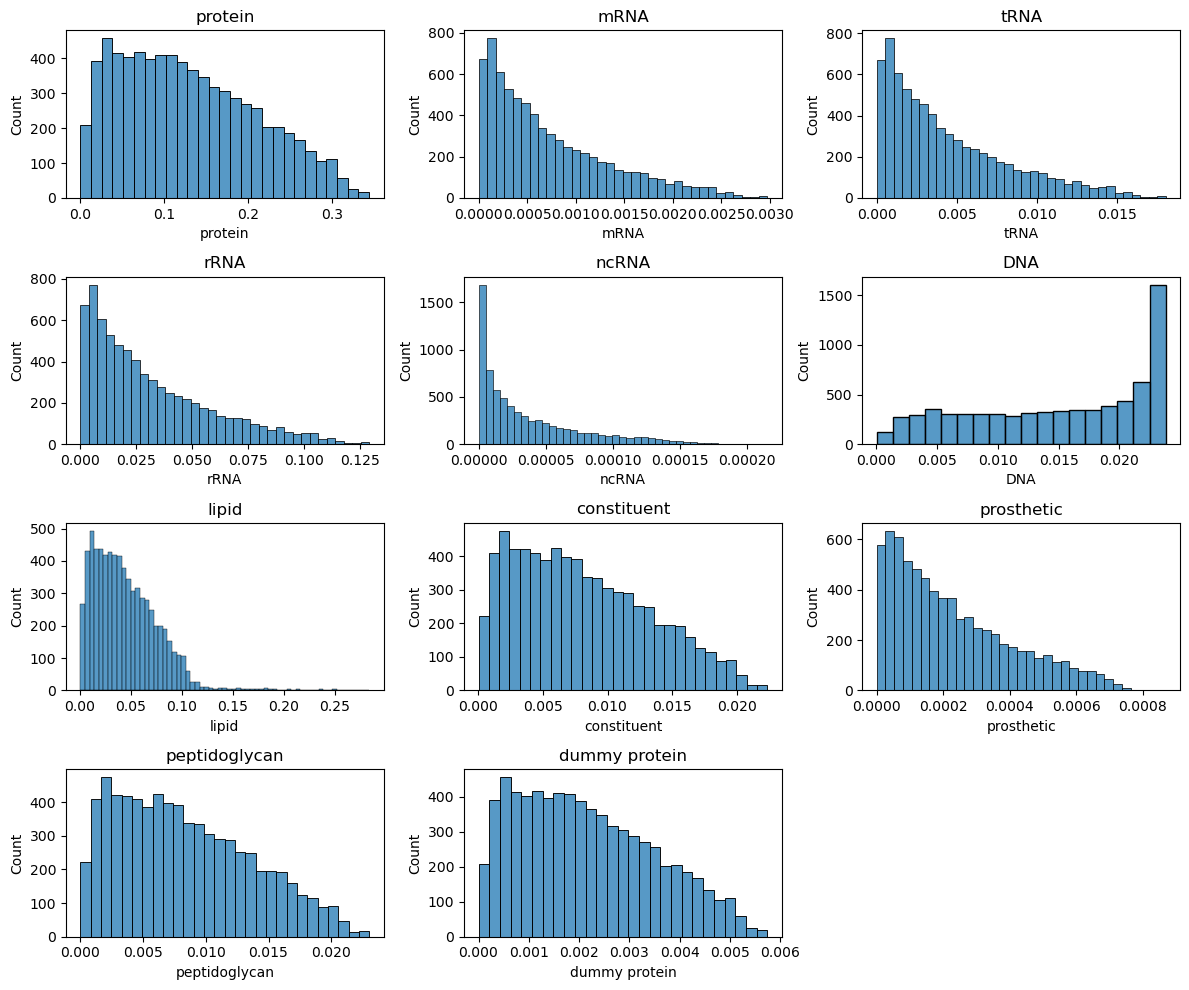

In [ ]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(12, 10)
)

axes = axes.flatten()

for ax, col in zip(axes, bm_plot.columns):
    sns.histplot(
        bm_plot[col],
        ax=ax,
    )
    ax.set_title(col)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [14]:
nitrogen_sources = [
    'arg_glc', 'arg_ac', 'arg_glyc',
    'nh4_glc', 'nh4_ac',
    'no3_glc', 'no3_ac', 'no3_glyc'
]

carbon_sources = ['glc', 'ac', 'lcts', 'glyc', 'succ']

bm_long = bm_plot.copy()
bm_long["source"] = data["source"].values

bm_long = bm_long.melt(
    id_vars="source",
    var_name="biomass_component",
    value_name="value"
)

bm_nitrogen = bm_long[bm_long["source"].isin(nitrogen_sources)]
bm_carbon = bm_long[bm_long["source"].isin(carbon_sources)]

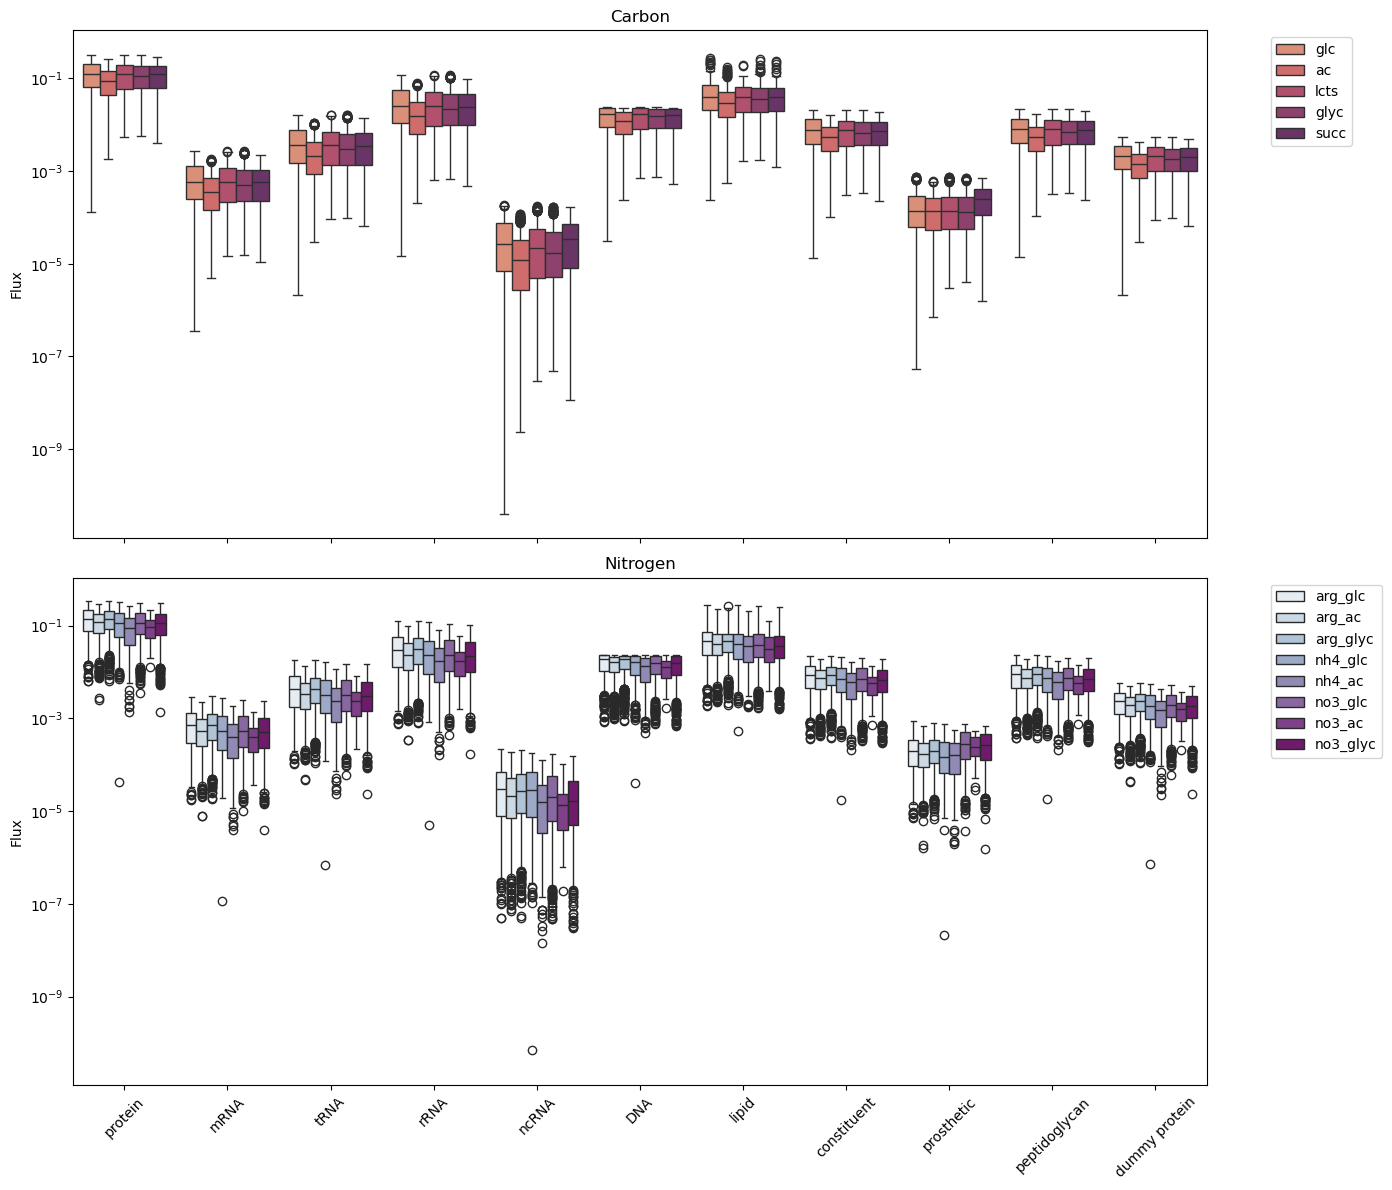

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharey=True)

sns.boxplot(
    data=bm_carbon,
    x="biomass_component",
    y="value",
    hue="source",
    ax=axes[0],
    palette="flare"
)

axes[0].set_xlabel("")
axes[0].set_ylabel('Flux')
axes[0].set_yscale('log')
axes[0].set_title("Carbon")
axes[0].set_xticklabels([])
axes[0].set_yscale('log')
axes[0].legend(bbox_to_anchor=(1.05, 1))

sns.boxplot(
    data=bm_nitrogen,
    x="biomass_component",
    y="value",
    hue="source",
    ax=axes[1],
    palette="BuPu"
)

axes[1].set_title("Nitrogen")
axes[1].set_ylabel('Flux')
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [6]:
color_map = sns.color_palette("crest", as_cmap=True)

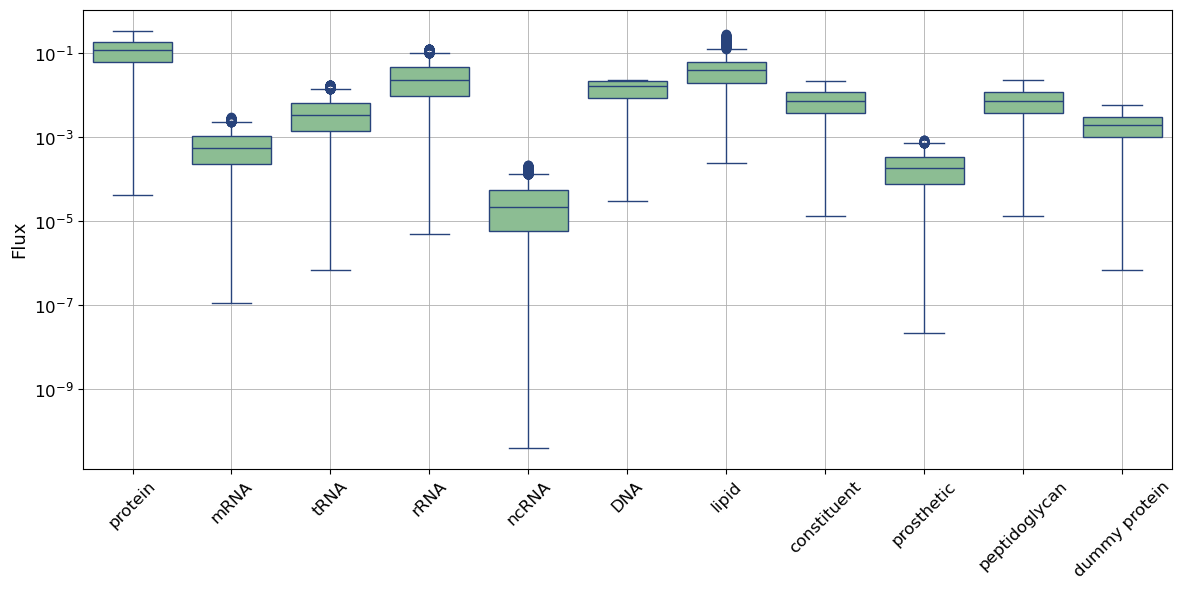

In [8]:
plt.figure(figsize=(12,6))

sns.boxplot(data=bm_plot, color=color_map(0.1), saturation=0.9, linecolor=color_map(0.9), linewidth=1.0)
plt.grid(True, linewidth=0.6)
# plt.title("Distribution by biomass component", fontsize=15, pad=15)
plt.xlabel("")
plt.ylabel("Flux", fontsize=13)
plt.yscale("log")
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

## Correlation

In [179]:
corr = target_corr.corr(method='spearman')

In [180]:
corr_annot = corr.iloc[:, 11:]
corr_annot = corr_annot.iloc[:-9]

corr_annot = corr_annot.reset_index()

corr_latex = corr_annot.to_latex(index=False, float_format="%.2f", column_format="lccccccccc")

print(corr_latex)

\begin{tabular}{lccccccccc}
\toprule
reaction & EX_o2_e & EX_glc__D_e & EX_ac_e & EX_lcts_e & EX_glyc_e & EX_succ_e & EX_arg__L_e & EX_nh4_e & EX_no3_e \\
\midrule
protein & -0.51 & 0.01 & -0.33 & 0.00 & -0.00 & -0.00 & 0.05 & 0.13 & -0.03 \\
mRNA & -0.52 & 0.01 & -0.33 & 0.00 & -0.00 & -0.00 & 0.05 & 0.13 & -0.03 \\
tRNA & -0.52 & 0.01 & -0.33 & 0.00 & -0.00 & -0.00 & 0.05 & 0.13 & -0.03 \\
rRNA & -0.52 & 0.01 & -0.33 & 0.00 & -0.00 & -0.00 & 0.05 & 0.13 & -0.03 \\
ncRNA & -0.50 & 0.04 & -0.32 & -0.02 & -0.05 & 0.06 & 0.03 & 0.18 & -0.06 \\
DNA & -0.53 & 0.00 & -0.32 & -0.00 & -0.01 & -0.01 & 0.05 & 0.13 & -0.03 \\
lipid & -0.56 & -0.00 & -0.28 & -0.02 & -0.02 & -0.01 & 0.04 & 0.13 & -0.03 \\
constituent & -0.53 & 0.00 & -0.32 & -0.00 & -0.01 & -0.01 & 0.05 & 0.13 & -0.03 \\
prosthetic & -0.48 & 0.01 & -0.26 & -0.10 & 0.01 & 0.07 & 0.01 & 0.04 & 0.19 \\
peptidoglycan & -0.53 & 0.00 & -0.32 & -0.00 & -0.01 & -0.01 & 0.05 & 0.13 & -0.03 \\
dummy protein & -0.51 & 0.01 & -0.33 & 0.00 & -

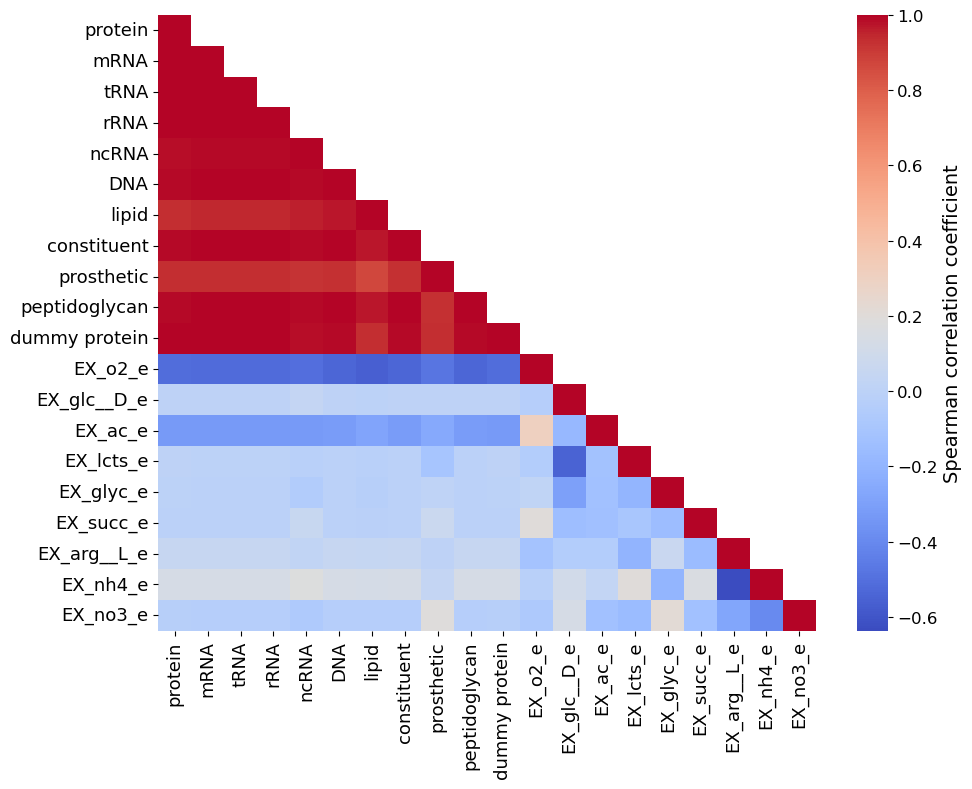

In [ ]:
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(10,8))

ax = sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    cbar_kws={'label': 'Spearman correlation coefficient'}
)

plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=90, fontsize=13)
plt.yticks(fontsize=13)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Spearman correlation coefficient', fontsize=14)

plt.tight_layout()
plt.show()

## Component vs growth rate

In [45]:
color_map = sns.color_palette("GnBu", as_cmap=True)

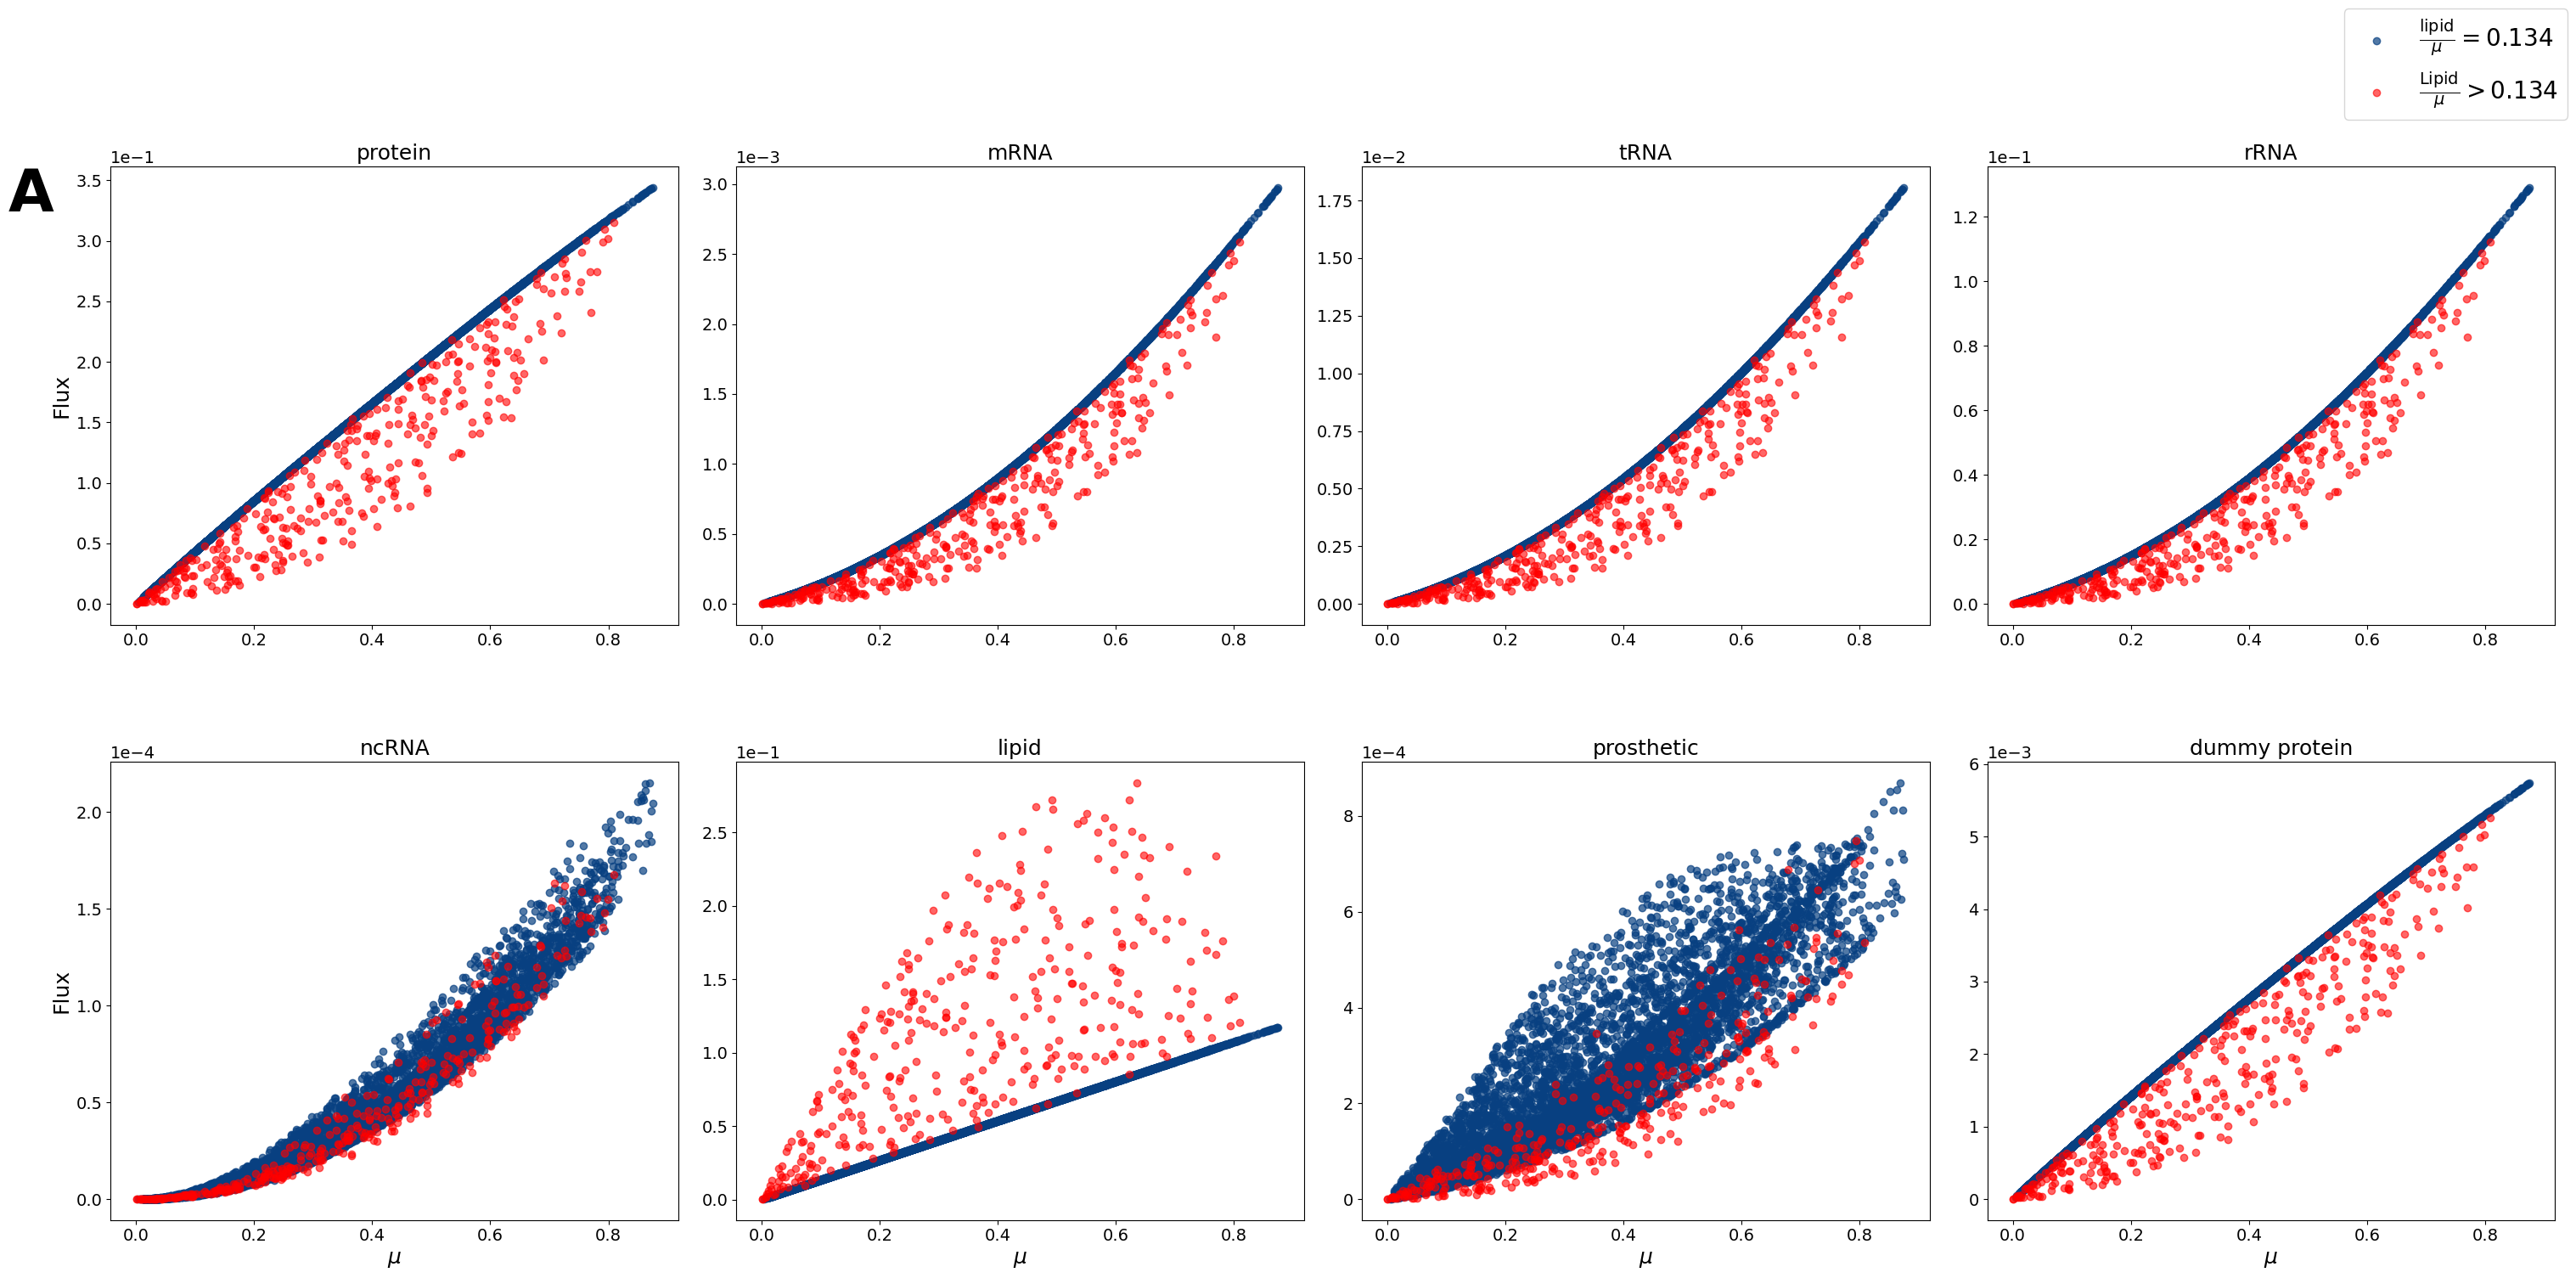

In [75]:
from matplotlib.ticker import ScalarFormatter

bm_plot_growth = bm_plot.copy()
bm_plot_growth = bm_plot_growth.drop(columns=['constituent', 'peptidoglycan', 'DNA'])
bm_plot_growth['biomass_dilution'] = data['biomass_dilution']

x_col = 'biomass_dilution'
y_cols = [col for col in bm_plot_growth.columns if col != x_col]
outlier_mask = data.loc[bm_plot_growth.index, 'outlier'] == 1

fig, axes = plt.subplots(2, 4, figsize=(30, 15))
axes = axes.flatten()

for i, y_col in enumerate(y_cols):
    
    axes[i].scatter(
        bm_plot_growth.loc[~outlier_mask, x_col],
        bm_plot_growth.loc[~outlier_mask, y_col],
        alpha=0.7,
        color=color_map(1.0),
        label=r'$\frac{\mathrm{lipid}}{\mu} = 0.134$' if i == 0 else None
    )
    

    axes[i].scatter(
        bm_plot_growth.loc[outlier_mask, x_col],
        bm_plot_growth.loc[outlier_mask, y_col],
        alpha=0.6,
        color='red',
        label=r'$\frac{\mathrm{Lipid}}{\mu} > 0.134$' if i == 0 else None
    )

    axes[i].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[i].yaxis.get_offset_text().set_fontsize(14)
    axes[i].tick_params(axis='both', labelsize=14)

    axes[i].set_xlabel(r'$\mu$', fontsize=18)
    axes[i].set_ylabel(f'{y_col}')
    axes[i].set_title(y_col, fontsize=18)
    # axes[i].set_facecolor('floralwhite')

    

axes[0].set_xlabel("")
axes[1].set_xlabel("")
axes[2].set_xlabel("")
axes[3].set_xlabel("")

axes[0].set_ylabel("Flux", fontsize=18)
axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[3].set_ylabel("")

axes[4].set_ylabel("Flux", fontsize=18)
axes[5].set_ylabel("")
axes[6].set_ylabel("")
axes[7].set_ylabel("")


for j in range(len(y_cols), len(axes)):
    fig.delaxes(axes[j])

fig.legend(loc='upper right', fontsize=20, bbox_to_anchor=(1, 1), borderaxespad=0)

# fig.legend(
#     loc='upper center',
#     bbox_to_anchor=(0.5, 1.00),
#     ncol=2,
#     fontsize=16,
#     frameon=False
# )

# plt.tight_layout(rect=[0, 0, 1, 0.92])
# plt.subplots_adjust(hspace=0.3)
# plt.show()

axes[0].text(-0.18, 1, "A", transform=axes[0].transAxes, fontsize=50, fontweight="bold", va="top")

plt.suptitle(r"kfejrfnkr", color="white", fontsize=40)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.3)
plt.show()

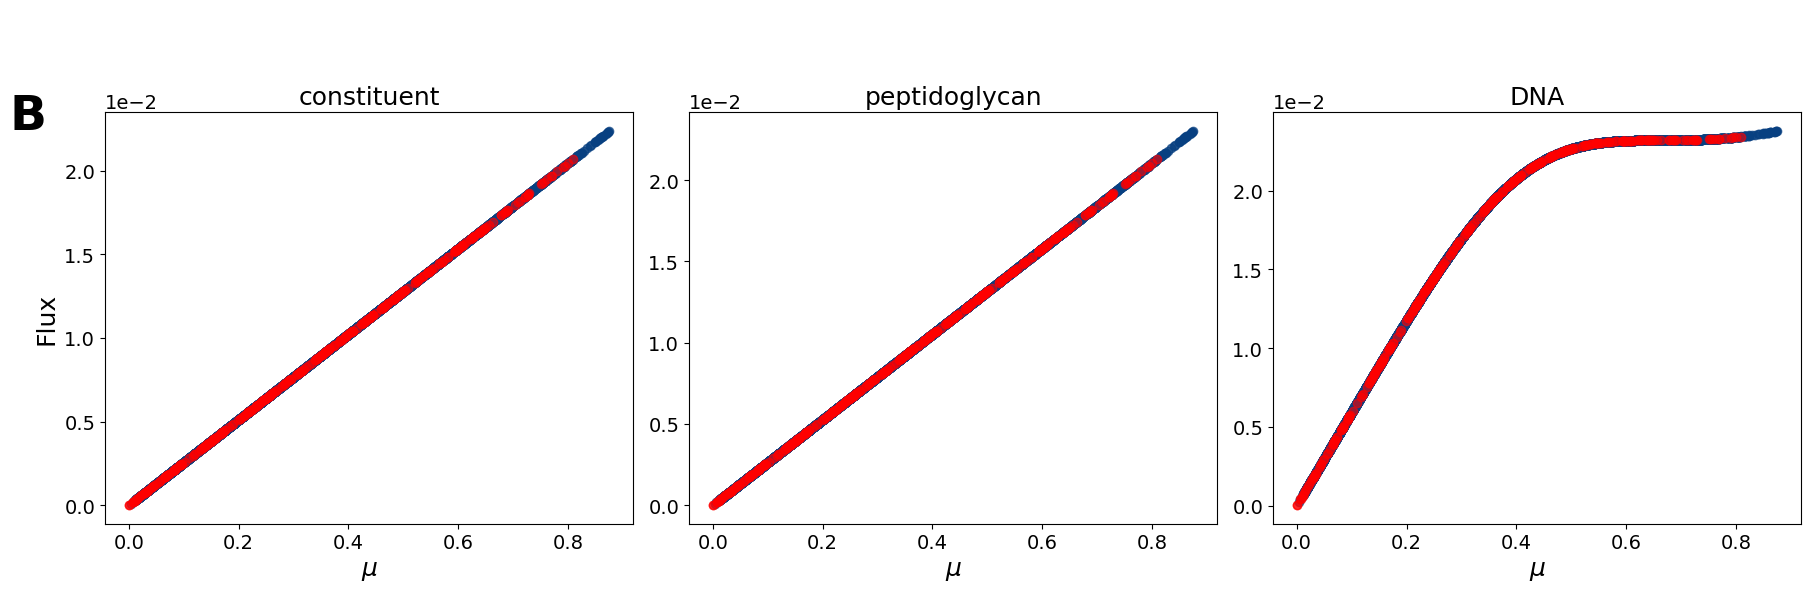

In [72]:
bm_plot_growth2 = bm_plot.copy()
bm_plot_growth2 = bm_plot_growth2[['constituent', 'peptidoglycan', 'DNA']]
bm_plot_growth2['biomass_dilution'] = data['biomass_dilution']

x_col = 'biomass_dilution'
y_cols = [col for col in bm_plot_growth2.columns if col != x_col]
outlier_mask = data.loc[bm_plot_growth2.index, 'outlier'] == 1

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for i, y_col in enumerate(y_cols):
    
    # Non-outliers (faint)
    axes[i].scatter(
        bm_plot_growth2.loc[~outlier_mask, x_col],
        bm_plot_growth2.loc[~outlier_mask, y_col],
        alpha=0.7,
        color=color_map(1.0),
        label=r'$\frac{\mathrm{lipid}}{\mu} = 0.134$' if i == 0 else None
    )
    
    # Outliers (highlighted)
    axes[i].scatter(
        bm_plot_growth2.loc[outlier_mask, x_col],
        bm_plot_growth2.loc[outlier_mask, y_col],
        alpha=0.6,
        color='red',
        label=r'$\frac{\mathrm{lipid}}{\mu} > 0.134$' if i == 0 else None
    )

    axes[i].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[i].yaxis.get_offset_text().set_fontsize(14)
    axes[i].tick_params(axis='both', labelsize=14)

    axes[i].set_xlabel(r'$\mu$', fontsize=18)
    axes[i].set_ylabel(f'{y_col}')
    axes[i].set_title(y_col, fontsize=18)
    # axes[i].set_facecolor('floralwhite')
    

axes[0].set_ylabel("Flux", fontsize=18)
axes[1].set_ylabel("")
axes[2].set_ylabel("")

# axes[1].set_yticklabels([])
# axes[2].set_yticklabels([])

# fig.legend(loc='upper right', fontsize=15, bbox_to_anchor=(1.1, 1), borderaxespad=0)

for j in range(len(y_cols), len(axes)):
    fig.delaxes(axes[j])

# axes[1].text(-0.18, 1.05, "B", transform=axes[1].transAxes, fontsize=20, fontweight="bold", va="top")
axes[0].text(-0.18, 1.05, "B", transform=axes[0].transAxes, fontsize=35, fontweight="bold", va="top")

plt.suptitle(r"kfejrfnkr", color="white", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.3)
plt.show()

In [101]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Build plotting dataframe
# bm_plot_growth = bm_plot.copy()

# plot_df = data.loc[bm_plot_growth.index].copy()
# plot_df["ncRNA"] = bm_plot_growth["ncRNA"]
# plot_df["growth_rate"] = data["biomass_dilution"]

# # Unique sources
# sources = plot_df["source"].unique()

# # Colormap
# cmap = plt.cm.tab10
# colors = {src: cmap(i % 10) for i, src in enumerate(sources)}

# fig, ax = plt.subplots(figsize=(8, 6))

# for src in sources:
#     mask = plot_df["source"] == src

#     ax.scatter(
#         plot_df.loc[mask, "growth_rate"],
#         plot_df.loc[mask, "ncRNA"],
#         color=colors[src],
#         alpha=0.8,
#         label=src
#     )

# ax.set_xlabel(r'$\mu$', fontsize=14)
# ax.set_ylabel('ncRNA', fontsize=14)
# ax.set_title('ncRNA vs Growth Rate', fontsize=16)

# ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
# ax.legend(title='Source', bbox_to_anchor=(1.05, 1), loc='upper left')

# plt.tight_layout()
# plt.show()

In [ ]:
bm_plot_growth = bm_plot.copy()

plot_df = data.loc[bm_plot_growth.index].copy()
plot_df["ncRNA"] = bm_plot_growth["ncRNA"]
plot_df["growth_rate"] = data["biomass_dilution"]

sources_to_plot = [
    'glc', 'ac', 'lcts', 'glyc', 'succ',
    'arg_glc', 'arg_ac', 'arg_glyc',
    'nh4_glc', 'nh4_ac',
    'no3_glc', 'no3_ac', 'no3_glyc'
]

# Keep only sources that actually exist in the dataframe
sources = [s for s in sources_to_plot if s in plot_df["source"].unique()]

n_sources = len(sources)

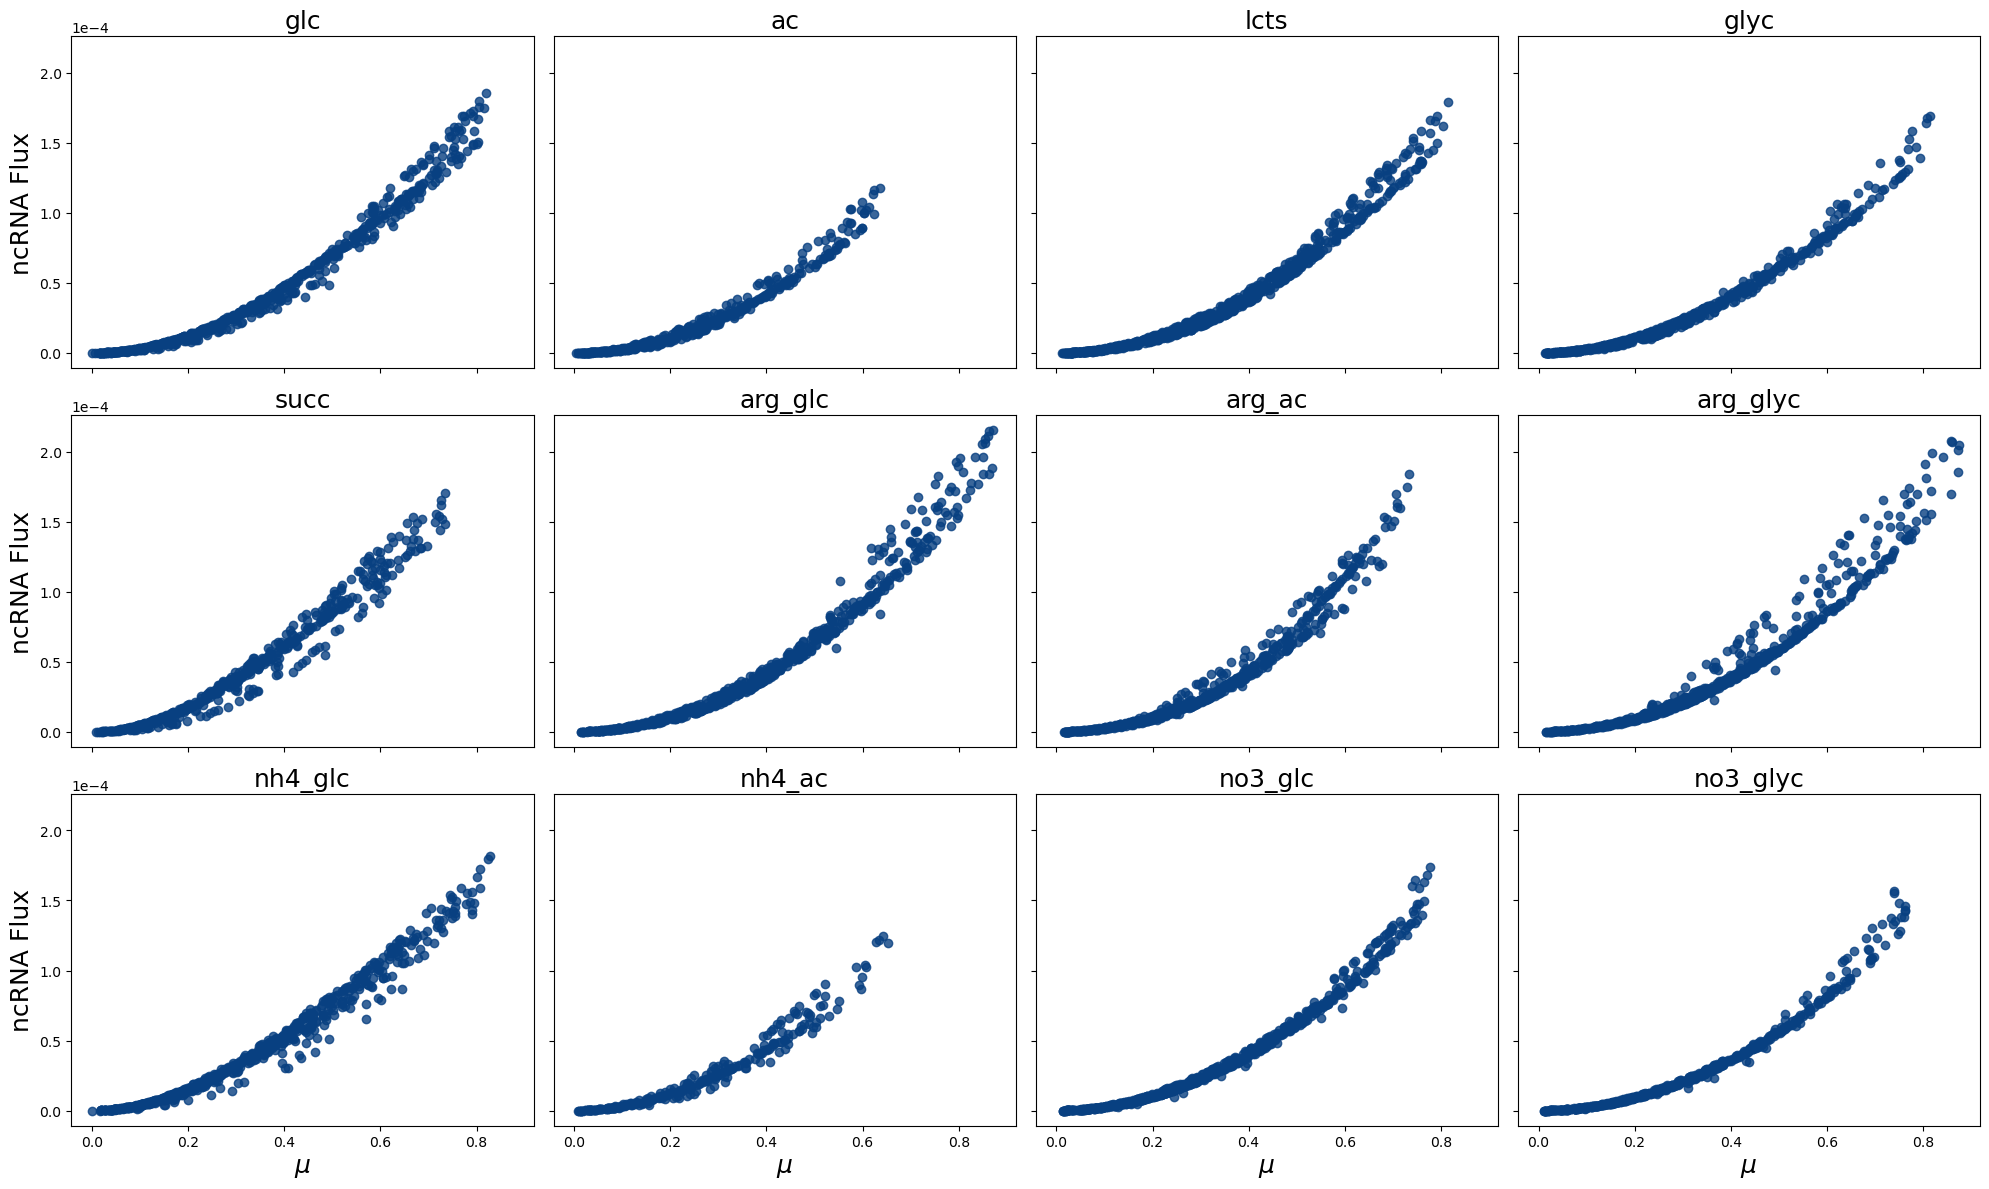

In [100]:
import matplotlib.pyplot as plt
import numpy as np

# Build plotting dataframe
plot_df = data.loc[bm_plot_growth.index].copy()
plot_df["ncRNA"] = bm_plot_growth["ncRNA"]
plot_df["growth_rate"] = data["biomass_dilution"]

outlier_mask = data.loc[bm_plot_growth.index, 'outlier'] == 1

sources_to_plot = [
    'glc', 'ac', 'lcts', 'glyc', 'succ',
    'arg_glc', 'arg_ac', 'arg_glyc',
    'nh4_glc', 'nh4_ac',
    'no3_glc', 'no3_glyc'
]

sources = [s for s in sources_to_plot if s in plot_df["source"].unique()]

n_sources = len(sources)
ncols = 4
nrows = int(np.ceil(n_sources / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(5*ncols, 4*nrows),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, src in zip(axes, sources):

    mask = plot_df["source"] == src

    # non-outliers
    ax.scatter(
        plot_df.loc[mask & ~outlier_mask, "growth_rate"],
        plot_df.loc[mask & ~outlier_mask, "ncRNA"],
        alpha=0.8,
        color=color_map(1.0)
    )

    # outliers
    ax.scatter(
        plot_df.loc[mask & outlier_mask, "growth_rate"],
        plot_df.loc[mask & outlier_mask, "ncRNA"],
        # color="red",
        color= color_map(1.0),       
        alpha=0.8
    )

    # ax.set_xlabel(r'$\mu$')
    # ax.set_ylabel("ncRNA flux")
    ax.set_title(src, fontsize=18)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

# Remove unused axes
for ax in axes[n_sources:]:
    fig.delaxes(ax)

for ax in axes[8:12]:
    ax.set_xlabel(r"$\mu$", fontsize=18)

axes[0].set_ylabel("ncRNA Flux", fontsize=18)
axes[4].set_ylabel("ncRNA Flux", fontsize=18)
axes[8].set_ylabel("ncRNA Flux", fontsize=18)


# fig.supxlabel(r'Growth rate ($\mu$)', fontsize=16)
# fig.supylabel('ncRNA flux', fontsize=16)

plt.tight_layout()
plt.show()

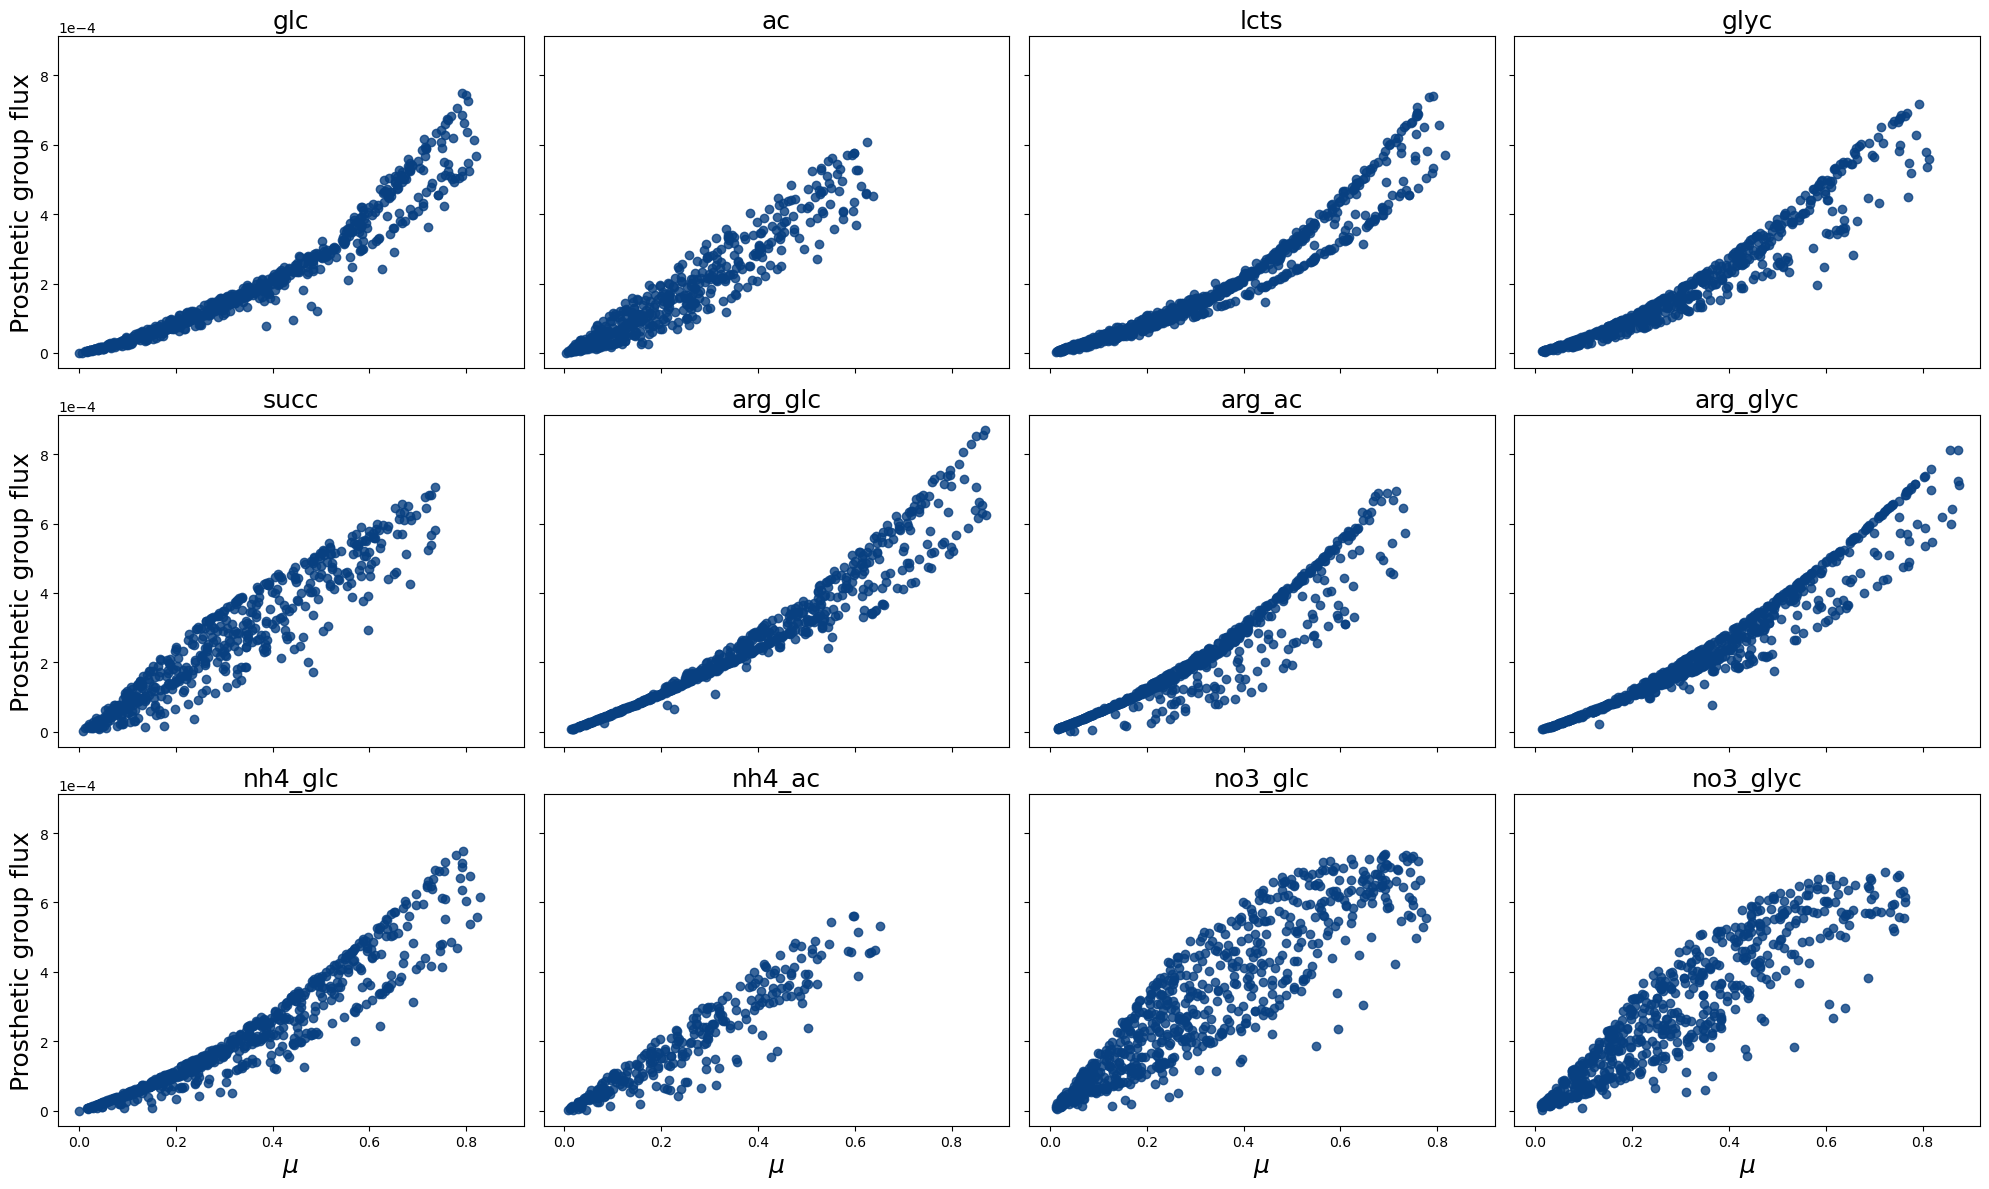

In [99]:
import matplotlib.pyplot as plt
import numpy as np

# Build plotting dataframe
plot_df = data.loc[bm_plot_growth.index].copy()
plot_df["prosthetic"] = bm_plot_growth["prosthetic"]
plot_df["growth_rate"] = data["biomass_dilution"]

outlier_mask = data.loc[bm_plot_growth.index, 'outlier'] == 1

sources_to_plot = [
    'glc', 'ac', 'lcts', 'glyc', 'succ',
    'arg_glc', 'arg_ac', 'arg_glyc',
    'nh4_glc', 'nh4_ac',
    'no3_glc', 'no3_glyc'
]

sources = [s for s in sources_to_plot if s in plot_df["source"].unique()]

n_sources = len(sources)
ncols = 4
nrows = int(np.ceil(n_sources / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(5*ncols, 4*nrows),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, src in zip(axes, sources):

    mask = plot_df["source"] == src

    # non-outliers
    ax.scatter(
        plot_df.loc[mask & ~outlier_mask, "growth_rate"],
        plot_df.loc[mask & ~outlier_mask, "prosthetic"],
        alpha=0.8,
        color=color_map(1.0)
    )

    # outliers
    ax.scatter(
        plot_df.loc[mask & outlier_mask, "growth_rate"],
        plot_df.loc[mask & outlier_mask, "prosthetic"],
        # color="red",
        color=color_map(1.0),
        alpha=0.8
    )

    ax.set_title(src, fontsize=18)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

# Remove unused axes
for ax in axes[n_sources:]:
    fig.delaxes(ax)

for ax in axes[8:12]:
    ax.set_xlabel(r"$\mu$", fontsize=18)

axes[0].set_ylabel("Prosthetic group flux", fontsize=18)
axes[4].set_ylabel("Prosthetic group flux", fontsize=18)
axes[8].set_ylabel("Prosthetic group flux", fontsize=18)

# fig.supxlabel(r'Growth rate ($\mu$)', fontsize=16)
# fig.supylabel('Prosthetic group flux', fontsize=16)

plt.tight_layout()
plt.show()

## PCA

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [10]:
color_map = sns.color_palette("crest", as_cmap=True)

In [47]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(bm_plot)

pca = PCA(n_components=10)
scores = pca.fit_transform(X_scaled)
variance =  pca.explained_variance_ratio_


pca_df = pd.DataFrame({
    "PC1": scores[:, 0],
    "PC2": scores[:, 1],
    "biomass_dilution": data["biomass_dilution"].values
})

# plt.figure(figsize=(10, 6))
# sc = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['biomass_dilution'], cmap=color_map, edgecolors='black', linewidths=0.3)

# cbar = plt.colorbar(sc)
# cbar.set_label(label=r"Growth rate", fontsize=15)
# cbar.ax.tick_params(labelsize=13)

# plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} Variance)', fontsize=13)
# plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} Variance)', fontsize=13)
# # plt.ylabel('', fontsize=13)

# # plt.xticks(fontsize=12)
# # plt.yticks([])

# # plt.title('PCA of biomass components', fontsize=17)
# plt.show()

In [48]:
plt.figure(figsize=(10, 6))


pca_df = pd.DataFrame({
    "PC1": scores[:, 0],
    "PC2": scores[:, 1],
    "outlier": data["outlier"].values,
    "biomass_dilution": data["biomass_dilution"].values
})


mask = pca_df['outlier'] == 1
# sc = plt.scatter(
#     pca_df.loc[~mask, 'PC1'],
#     pca_df.loc[~mask, 'PC2'],
#     c=pca_df.loc[~mask, 'biomass_dilution'],
#     cmap=color_map,
#     edgecolors='black',
#     linewidths=0.3,
#     alpha=0.7
# )


# cbar = plt.colorbar(sc)
# cbar.ax.set_visible(False)

# plt.scatter(
#     pca_df.loc[mask, 'PC1'],
#     pca_df.loc[mask, 'PC2'],
#     color='red',
#     edgecolors='black',
#     linewidths=0.3,
#     alpha=0.7,
#     label=r'$\frac{\mathrm{Lipid}}{\mu} > 0.134$'
# )

# plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} Variance)', fontsize=13)
# plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} Variance)', fontsize=13)

# # fig.legend(loc='upper right', fontsize=20)

# plt.legend(frameon=False, fontsize=15)
# plt.show()

<Figure size 1000x600 with 0 Axes>

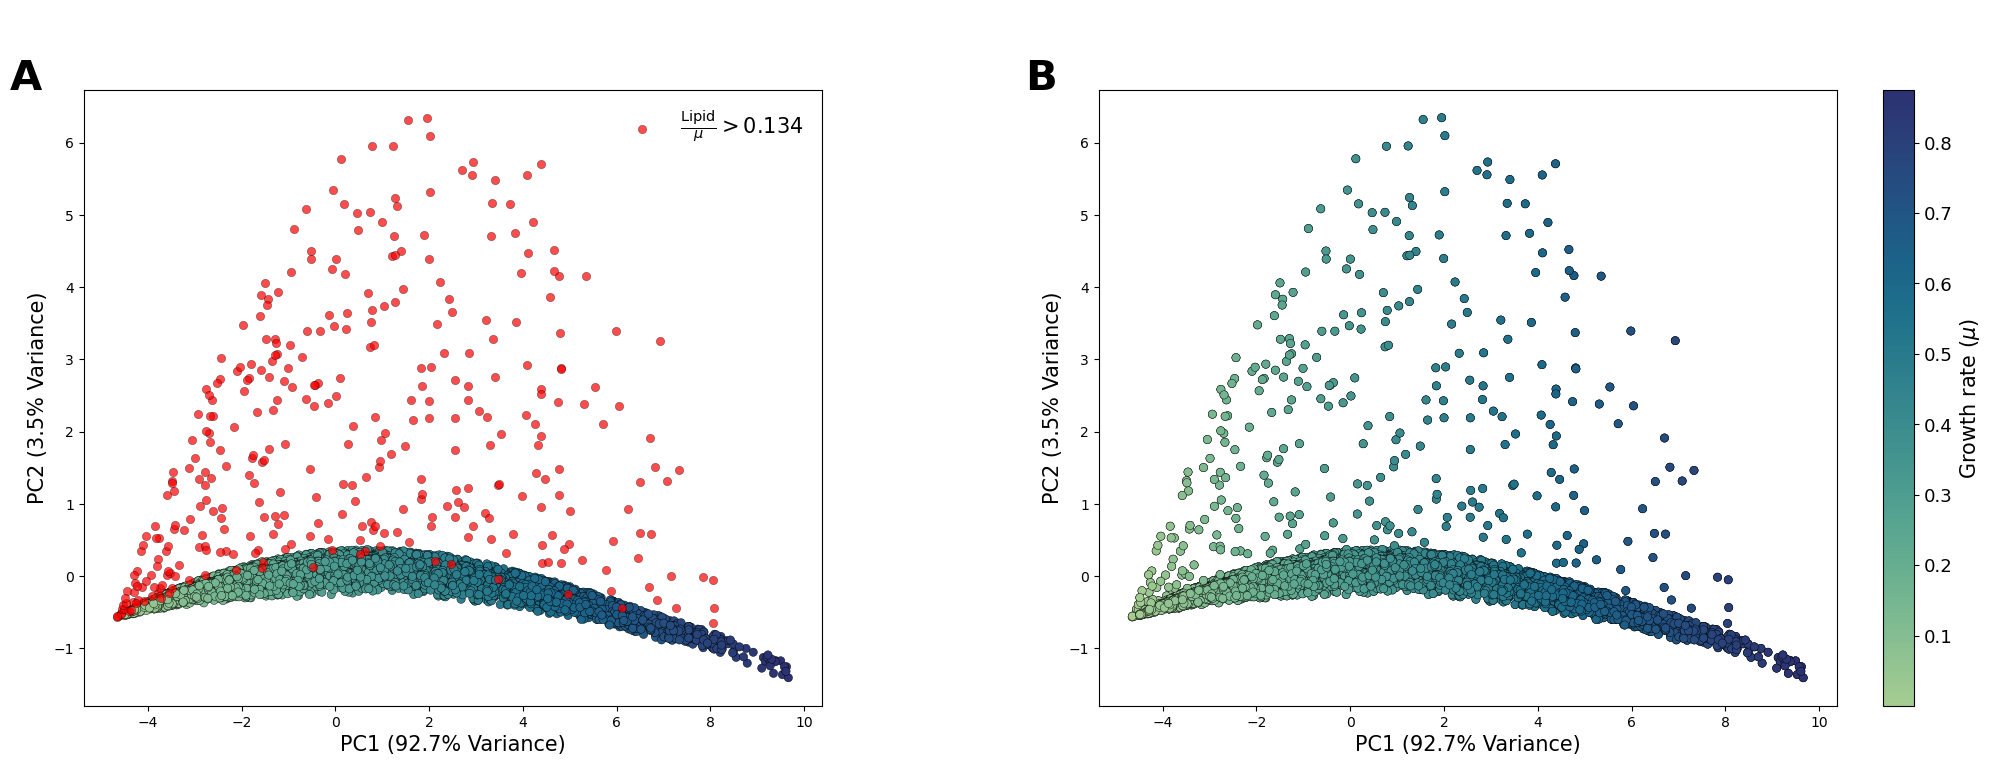

In [44]:
# x = nc_TU['biomass_dilution']
# outliers_nc = nc_TU.loc[nc_TU.index, "outlier"] == 1
# outliers_all = data.loc[data.index, 'outlier'] == 1

fig, axes = plt.subplots(1, 2, figsize=(25, 8))

sc = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['biomass_dilution'], cmap=color_map, edgecolors='black', linewidths=0.3)

# Plot first column
axes[0].scatter(pca_df.loc[~mask, 'PC1'], pca_df.loc[~mask, 'PC2'], c=pca_df.loc[~mask, 'biomass_dilution'], cmap=color_map, edgecolors='black', linewidths=0.3)
axes[0].scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'], color='red', edgecolors='black', linewidths=0.3, alpha=0.7, label=r'$\frac{\mathrm{Lipid}}{\mu} > 0.134$')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} Variance)', fontsize=15)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} Variance)', fontsize=15)

cbar0 = fig.colorbar(sc, ax=axes[0])
cbar0.ax.set_visible(False)

axes[0].legend(frameon=False, fontsize=15)

# Plot second column
axes[1].scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['biomass_dilution'], cmap=color_map, edgecolors='black', linewidths=0.3)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} Variance)', fontsize=15)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} Variance)', fontsize=15)
# axes[1].set_ylabel("")

cbar1 = fig.colorbar(sc, ax=axes[1])
cbar1.set_label(r"Growth rate ($\mu$)", fontsize=15)
cbar1.ax.tick_params(labelsize=13)

# Panel labels
axes[0].text(-0.1, 1.05, "A", transform=axes[0].transAxes, fontsize=30, fontweight="bold", va="top")
axes[1].text(-0.1, 1.05, "B", transform=axes[1].transAxes, fontsize=30, fontweight="bold", va="top")

plt.suptitle("knfk", color="white", fontsize=25)
# fig.legend(fontsize=15)
plt.subplots_adjust(wspace=0.1)
plt.show()

In [27]:
loadings = pd.DataFrame(
    pca.components_.T[:, :2],
    index=bm_plot.columns,
    columns=["PC1", "PC2"]
)


loadings = loadings.sort_values(by='PC1', ascending=False)
loadings = loadings.reset_index()
# loadings = loadings.reset_index().rename(columns={'index': 'Reaction'})

latex_loadings = loadings.to_latex(index=False, float_format="%.2f", column_format="lcc")
print(latex_loadings)

\begin{tabular}{lcc}
\toprule
reaction & PC1 & PC2 \\
\midrule
peptidoglycan & 0.31 & 0.07 \\
constituent & 0.31 & 0.07 \\
protein & 0.31 & -0.09 \\
dummy protein & 0.31 & -0.09 \\
tRNA & 0.31 & -0.18 \\
rRNA & 0.31 & -0.18 \\
mRNA & 0.31 & -0.18 \\
ncRNA & 0.30 & -0.16 \\
prosthetic & 0.29 & -0.25 \\
DNA & 0.29 & 0.31 \\
lipid & 0.26 & 0.83 \\
\bottomrule
\end{tabular}



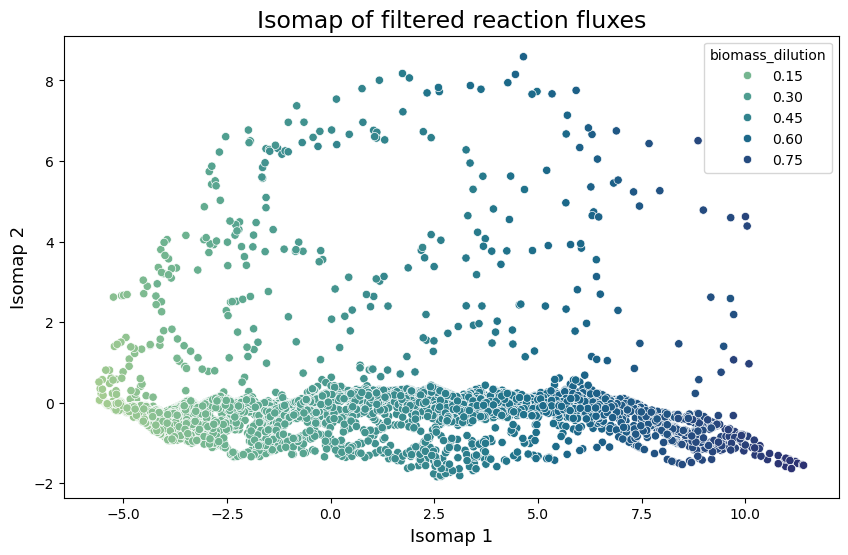

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import Isomap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


scaler = StandardScaler()
X_scaled = scaler.fit_transform(bm_plot)


isomap = Isomap(
    n_components=2,     # usually visualize in 2D
    n_neighbors=5      # tune this
)

scores = isomap.fit_transform(X_scaled)


iso_df = pd.DataFrame({
    "ISO1": scores[:, 0],
    "ISO2": scores[:, 1],
    "biomass_dilution": data["biomass_dilution"].values,
    "source": data['source']
})

plt.figure(figsize=(10, 6))

sc = sns.scatterplot(
    data=iso_df,
    x="ISO1",
    y="ISO2",
    hue="biomass_dilution",
    palette="crest",
    alpha=1.0
)

plt.xlabel("Isomap 1", fontsize=13)
plt.ylabel("Isomap 2", fontsize=13)

plt.title('Isomap of filtered reaction fluxes', fontsize=17)

plt.show()

# Biomass composition analysis - mass fractions

* plotte protein vs source uptake; vet at RNA/DNA er lineært, så holder med protein. Skal undersøke DNA også

In [22]:
bm_comp = bm_plot.copy()

bm_comp['RNA'] = bm_comp['ncRNA'] + bm_comp['rRNA'] + bm_comp['mRNA'] + bm_comp['tRNA']
bm_comp.drop(columns=['ncRNA', 'rRNA', 'mRNA', 'tRNA'], inplace=True)

row_totals = bm_comp.sum(axis=1)
bm_frac = bm_comp.copy()
bm_frac = bm_frac.div(row_totals, axis=0)

bm_frac = bm_frac[['protein', 'DNA', 'RNA', 'prosthetic']]
bm_frac = bm_frac.rename(columns=lambda col: f"{col}_frac")

In [24]:
bm_comp[['protein_frac', 'DNA_frac', 'RNA_frac', 'prosthetic_frac']] = bm_frac[['protein_frac', 'DNA_frac', 'RNA_frac', 'prosthetic_frac']]
bm_comp['source'] = data['source']
bm_comp['outlier'] = data['outlier']
bm_comp[ex_rxns] = -data[ex_rxns]

In [25]:
color_map = sns.color_palette("crest", as_cmap=True)

In [26]:
sources_to_plot = [
    'glc', 'ac', 'lcts', 'glyc', 'succ',
    'arg_glc', 'arg_ac', 'arg_glyc',
    'nh4_glc', 'nh4_ac',
    'no3_glc', 'no3_ac', 'no3_glyc'
]

carbon_plot = ['glc', 'ac', 'lcts', 'glyc', 'succ']
nitrogen_plot = ['arg_glc', 'arg_ac', 'arg_glyc', 'nh4_glc', 'nh4_ac', 'no3_glc', 'no3_ac', 'no3_glyc']

source_to_ex = {
    'glc': 'EX_glc__D_e',
    'ac': 'EX_ac_e',
    'lcts': 'EX_lcts_e',
    'glyc': 'EX_glyc_e',
    'succ': 'EX_succ_e',
    'arg': 'EX_arg__L_e',
    'nh4': 'EX_nh4_e',
    'no3': 'EX_no3_e'
}

In [18]:
bm_comp['biomass_dilution'] = data['biomass_dilution']

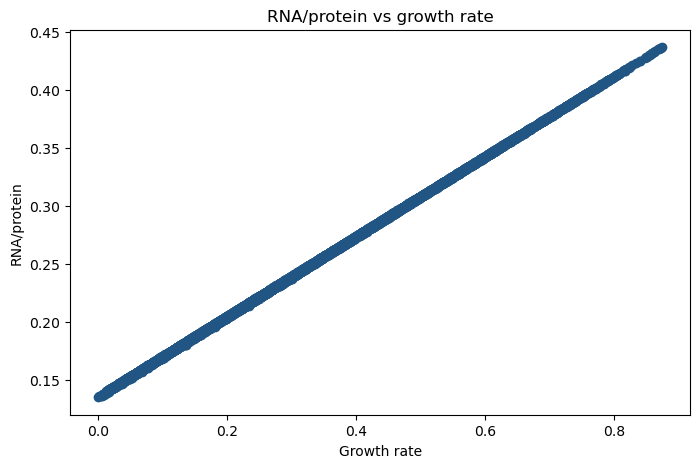

In [12]:
plt.figure(figsize=(8,5))

plt.scatter(bm_comp['biomass_dilution'], bm_comp['RNA']/bm_comp['protein'], color=color_map(0.8))

plt.xlabel('Growth rate')
plt.ylabel('RNA/protein')

plt.title('RNA/protein vs growth rate')
plt.show()

In [6]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import math


def plot_by_source_subplots(
    plot_df,
    y_col,
    source_col='source',
    source_to_xcol=None,
    sources_to_plot=None,
    dataset=None,
    color_col=None,
    cmap='viridis',
    ncols=4,
    figsize_per_col=(5, 4),
    point_alpha=0.6,
    non_outlier_size=36,
    outlier_col=None,
    outlier_size=80,
    outlier_marker='^',
    outlier_label='Outlier',
    y_label = None,
    colorbar_label= None
):
    """
    Plot one subplot per source value, where the x-variable is chosen from a
    mapped dataframe column based on the first token of the source name.
    Points are colored by a gradient based on a column of choice, with a single
    shared colorbar across all subplots.

    Outliers (if outlier_col is provided) are drawn on top of regular points
    with a distinct marker and larger size, but share the same color gradient.

    Parameters
    ----------
    plot_df : pd.DataFrame
        DataFrame containing source column, y column, and x columns.
    y_col : str
        Column name to plot on the y-axis.
    source_col : str, default='source'
        Column containing source names like 'glc', 'arg_glc', etc.
    source_to_xcol : dict
        Mapping from source token -> dataframe x column.
        Example:
            {
                'glc': 'EX_glc__D_e',
                'ac': 'EX_ac_e',
                'arg': 'EX_arg__L_e',
                ...
            }
    sources_to_plot : list, optional
        Ordered list of full source labels to include as subplots.
        If None, all unique values in source_col are used.
    dataset : pd.DataFrame, optional
        DataFrame containing color_col and/or outlier_col, aligned by index.
        If None, plot_df is used.
    color_col : str, optional
        Column name used to determine the color gradient.
        If None, points are plotted with a single default color.
    cmap : str or Colormap, default='viridis'
        Colormap to use for the gradient.
    ncols : int, default=4
        Number of subplot columns.
    figsize_per_col : tuple, default=(5, 4)
        Width, height per subplot grid unit.
    point_alpha : float, default=0.6
        Alpha transparency for all scatter points.
    non_outlier_size : int, default=36
        Marker size for regular (non-outlier) points.
    outlier_col : str, optional
        Column (in dataset or plot_df) identifying outliers (1 = outlier).
        If None, no outlier distinction is made.
    outlier_size : int, default=80
        Marker size for outlier points.
    outlier_marker : str, default='^'
        Marker style for outlier points.
    outlier_label : str, default='Outlier'
        Legend label for outlier points.

    Returns
    -------
    fig, axes
    """
    if source_to_xcol is None:
        raise ValueError("source_to_xcol must be provided.")

    df = plot_df.copy()

    if sources_to_plot is not None:
        df = df[df[source_col].isin(sources_to_plot)].copy()
        sources_present = [s for s in sources_to_plot if s in df[source_col].unique()]
    else:
        sources_present = list(df[source_col].dropna().unique())

    if len(sources_present) == 0:
        raise ValueError("No matching sources found to plot.")


    df['x_token'] = df[source_col].str.split('_').str[0]
    df['x_col'] = df['x_token'].map(source_to_xcol)


    df = df.dropna(subset=['x_col']).copy()

  
    df['x_val'] = [df.loc[idx, col_name] for idx, col_name in df['x_col'].items()]

   
    if color_col is not None:
        color_source = dataset if (dataset is not None and color_col in dataset.columns) else df
        df['color_val'] = color_source.loc[df.index, color_col]

        vmin = df['color_val'].min()
        vmax = df['color_val'].max()
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        scalar_mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
        scalar_mappable.set_array([])
    else:
        norm = None
        scalar_mappable = None

    # Resolve outlier mask
    if outlier_col is not None:
        outlier_source = dataset if (dataset is not None and outlier_col in dataset.columns) else df
        df['is_outlier'] = (outlier_source.loc[df.index, outlier_col] == 1)
    else:
        df['is_outlier'] = False

    n = len(sources_present)
    nrows = math.ceil(n / ncols)

   
    colorbar_width_ratio = 0.08 if scalar_mappable is not None else 0
    fig = plt.figure(figsize=(figsize_per_col[0] * ncols, figsize_per_col[1] * nrows))


    if scalar_mappable is not None:
        gs = gridspec.GridSpec(
            nrows, ncols + 1,
            width_ratios=[1] * ncols + [colorbar_width_ratio],
            figure=fig
        )
        cbar_ax = fig.add_subplot(gs[:, ncols])
    else:
        gs = gridspec.GridSpec(nrows, ncols, figure=fig)
        cbar_ax = None

    axes = [fig.add_subplot(gs[i // ncols, i % ncols]) for i in range(n)]

    legend_handles = []

    for i, src in enumerate(sources_present):
        ax = axes[i]
        sub = df[df[source_col] == src]

        if sub.empty:
            ax.set_visible(False)
            continue

        normal = sub[~sub['is_outlier']]
        outliers = sub[sub['is_outlier']]


        scatter_kw = dict(alpha=point_alpha)
        if scalar_mappable is not None:
            scatter_kw.update(cmap=cmap, norm=norm)

        def _scatter(ax, rows, marker='o', size=non_outlier_size, **extra):
            kw = {**scatter_kw, **extra}
            if scalar_mappable is not None:
                return ax.scatter(
                    rows['x_val'], rows[y_col],
                    c=rows['color_val'],
                    s=size, marker=marker, **kw
                )
            else:
                return ax.scatter(
                    rows['x_val'], rows[y_col],
                    color='steelblue',
                    s=size, marker=marker, **kw
                )


        if not normal.empty:
            _scatter(ax, normal, marker='o', size=non_outlier_size, zorder=2)

        if not outliers.empty:
            sc = _scatter(ax, outliers, marker=outlier_marker, size=outlier_size, zorder=3)
            # Collect one legend handle from the first subplot that has outliers
            if i == next((j for j, s in enumerate(sources_present)
                          if not df[(df[source_col] == s) & df['is_outlier']].empty), None):
                import matplotlib.lines as mlines
                handle = mlines.Line2D(
                    [], [], color='grey', marker=outlier_marker,
                    linestyle='None', markersize=9, label=outlier_label
                )
                legend_handles.append(handle)

        ax.set_title(src, fontsize=15)
        ax.set_xlabel(sub['x_col'].iloc[0], fontsize=12)

        if y_label is None:
            ax.set_ylabel(y_col, fontsize=15)
        else:
            ax.set_ylabel(y_label, fontsize=15)


    for k in range(n, nrows * ncols):
        dummy = fig.add_subplot(gs[k // ncols, k % ncols])
        dummy.set_visible(False)


    if scalar_mappable is not None and cbar_ax is not None:
        cbar = fig.colorbar(scalar_mappable, cax=cbar_ax)
        cbar.ax.tick_params(labelsize=13)

        # cbar.set_ticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.55])
        if colorbar_label is None:
            cbar.set_label(color_col, fontsize=15, labelpad=20)
        else:
            cbar.set_label(colorbar_label, fontsize=15, labelpad=20)

    if legend_handles:
        fig.legend(handles=legend_handles, loc='upper right', fontsize=15)

    plt.tight_layout()
    return fig, axes

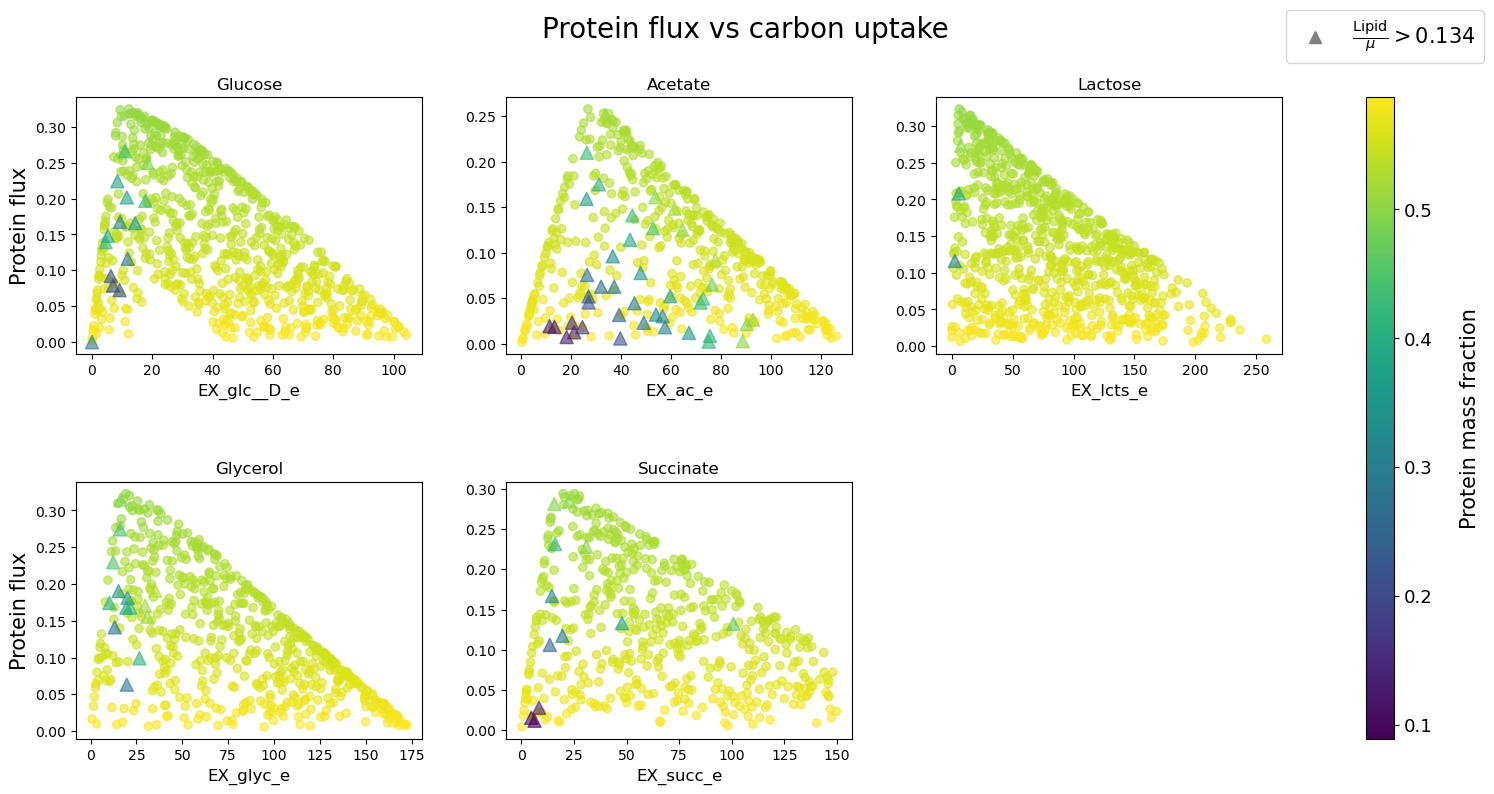

In [210]:
fig, axes = plot_by_source_subplots(
    plot_df=bm_comp,
    y_col='protein',
    color_col = 'protein_frac',
    source_to_xcol=source_to_ex,
    sources_to_plot=carbon_plot,
    dataset=data,
    cmap ='viridis',
    ncols=3,
    outlier_col='outlier',
    outlier_marker = '^',
    outlier_size = 90,
    y_label = 'Protein flux',
    colorbar_label = 'Protein mass fraction',
    outlier_label=r'$\frac{\mathrm{Lipid}}{\mu} > 0.134$'
)

# plt.suptitle('Protein mass fraction across sampled carbon phenotype phase planes', fontsize=20)
plt.suptitle('Protein flux vs carbon uptake', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.subplots_adjust(hspace=0.5)

axes[0].set_title("Glucose")
axes[1].set_title("Acetate")
axes[2].set_title("Lactose")
axes[3].set_title("Glycerol")
axes[4].set_title("Succinate")


axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[4].set_ylabel("")

plt.show()

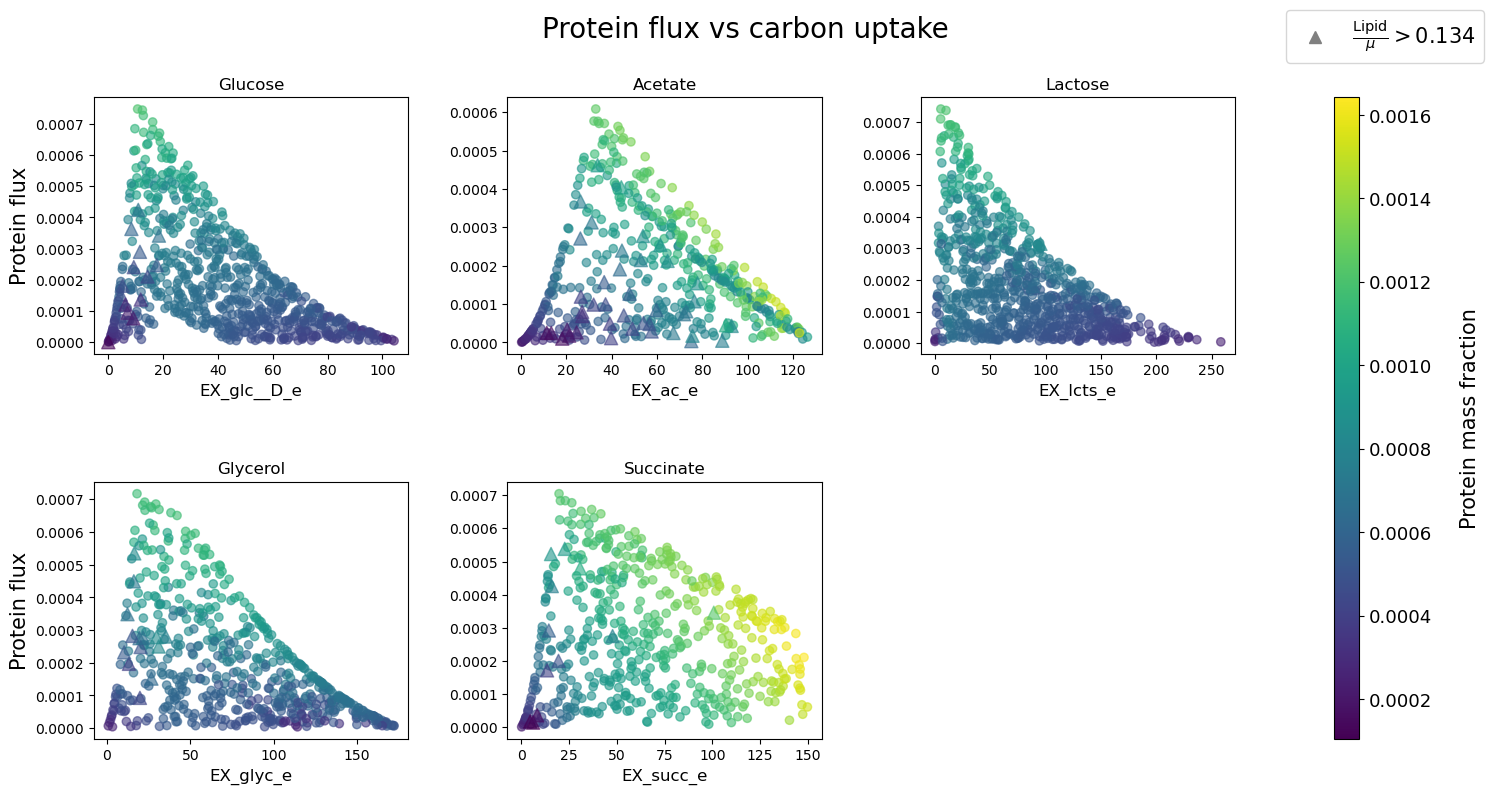

In [27]:
fig, axes = plot_by_source_subplots(
    plot_df=bm_comp,
    y_col='prosthetic',
    color_col = 'prosthetic_frac',
    source_to_xcol=source_to_ex,
    sources_to_plot=carbon_plot,
    dataset=data,
    cmap ='viridis',
    ncols=3,
    outlier_col='outlier',
    outlier_marker = '^',
    outlier_size = 90,
    y_label = 'Protein flux',
    colorbar_label = 'Protein mass fraction',
    outlier_label=r'$\frac{\mathrm{Lipid}}{\mu} > 0.134$'
)

# plt.suptitle('Protein mass fraction across sampled carbon phenotype phase planes', fontsize=20)
plt.suptitle('Protein flux vs carbon uptake', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.subplots_adjust(hspace=0.5)

axes[0].set_title("Glucose")
axes[1].set_title("Acetate")
axes[2].set_title("Lactose")
axes[3].set_title("Glycerol")
axes[4].set_title("Succinate")


axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[4].set_ylabel("")

plt.show()

In [21]:
bm_comp.columns

Index(['protein', 'DNA', 'lipid', 'constituent', 'prosthetic', 'peptidoglycan',
       'dummy protein', 'RNA', 'protein_frac', 'DNA_frac', 'RNA_frac',
       'source', 'outlier', 'EX_o2_e', 'EX_glc__D_e', 'EX_ac_e', 'EX_lcts_e',
       'EX_glyc_e', 'EX_succ_e', 'EX_arg__L_e', 'EX_nh4_e', 'EX_no3_e',
       'biomass_dilution'],
      dtype='str', name='reaction')

In [ ]:
fig, axes = plot_by_source_subplots(
    plot_df=bm_comp,
    y_col='protein',
    color_col = 'protein_frac',
    source_to_xcol=source_to_ex,
    sources_to_plot=carbon_plot,
    dataset=data,
    cmap ='viridis',
    ncols=3,
    outlier_col='outlier',
    outlier_marker = '^',
    outlier_size = 90,
    y_label = 'Protein flux',
    colorbar_label = 'Protein mass fraction',
    outlier_label=r'$\frac{\mathrm{Lipid}}{\mu} > 0.134$'
)

# plt.suptitle('Protein mass fraction across sampled carbon phenotype phase planes', fontsize=20)
plt.suptitle('Protein flux vs carbon uptake', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.subplots_adjust(hspace=0.5)

axes[0].set_title("Glucose")
axes[1].set_title("Acetate")
axes[2].set_title("Lactose")
axes[3].set_title("Glycerol")
axes[4].set_title("Succinate")


axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[4].set_ylabel("")

plt.show()

In [211]:
bm_plot['biomass_dilution'] = data['biomass_dilution']

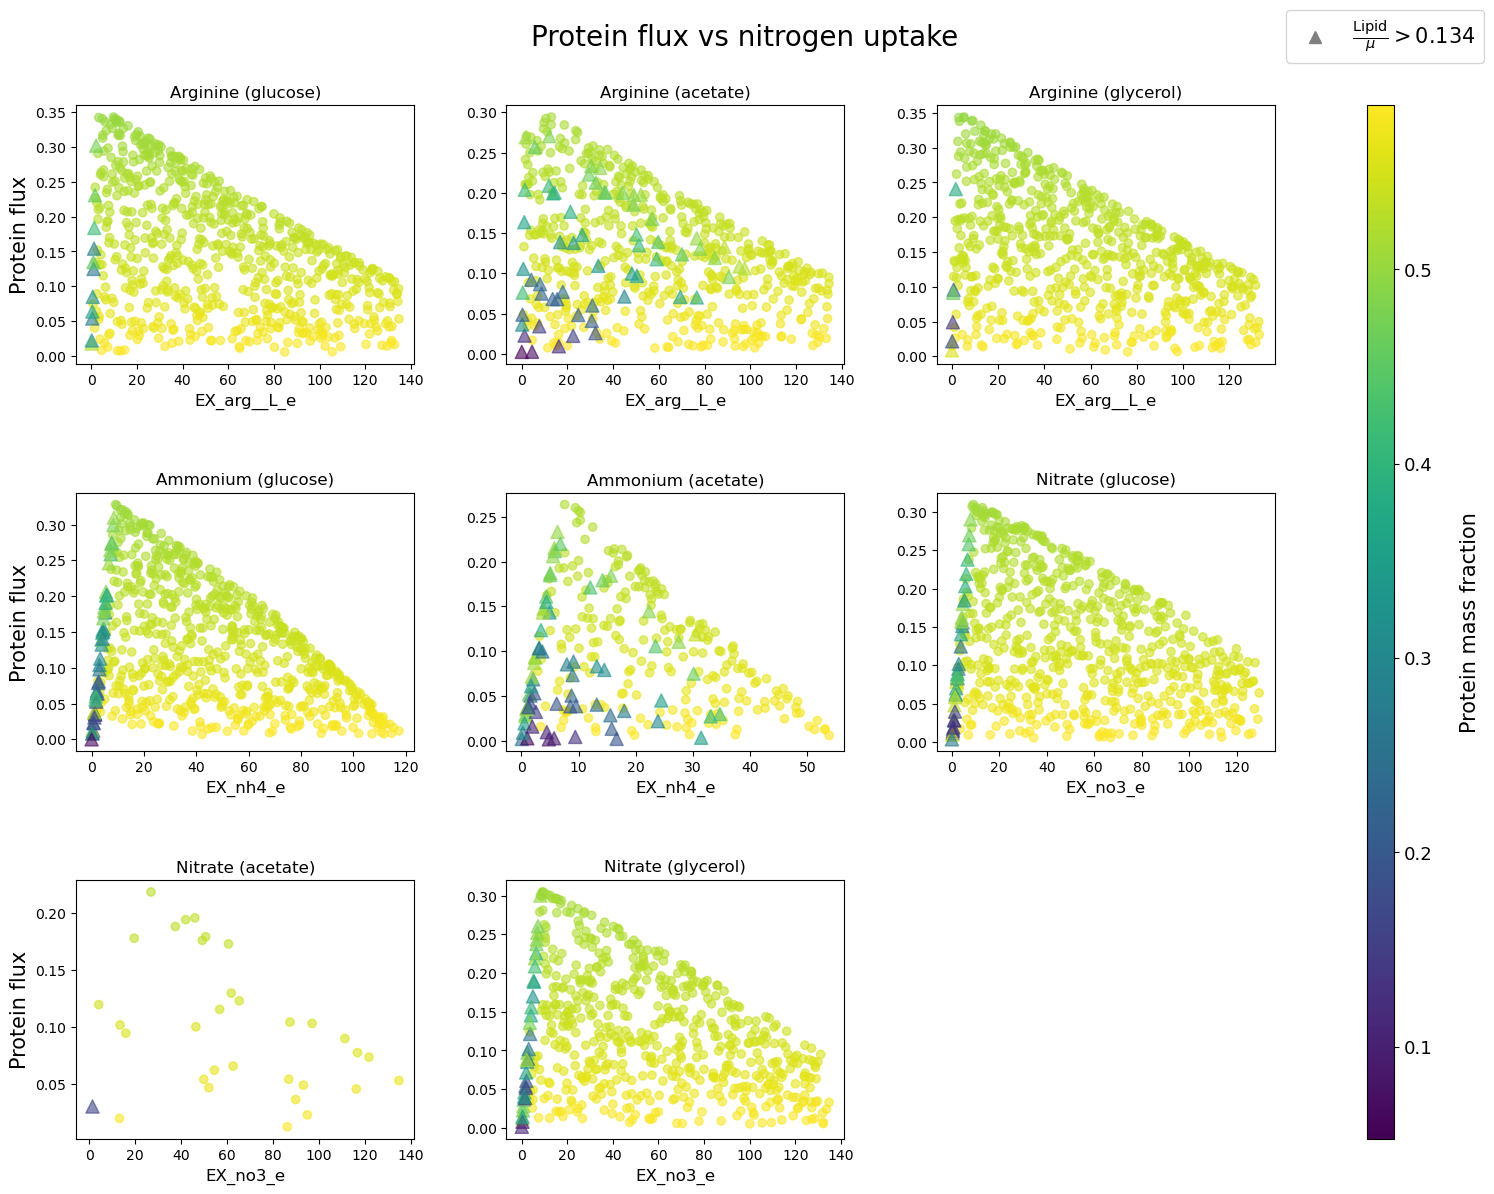

In [216]:
fig, axes = plot_by_source_subplots(
    plot_df=bm_comp,
    y_col='protein',
    color_col = 'protein_frac',
    source_to_xcol=source_to_ex,
    sources_to_plot=nitrogen_plot,
    dataset=data,
    cmap ='viridis',
    ncols=3,
    outlier_col='outlier',
    outlier_marker = '^',
    outlier_size = 90,
    y_label = 'Protein flux',
    colorbar_label = 'Protein mass fraction',
    outlier_label= r'$\frac{\mathrm{Lipid}}{\mu} > 0.134$')

plt.suptitle('Protein flux vs nitrogen uptake', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.subplots_adjust(hspace=0.5)

axes[0].set_title("Arginine (glucose)")
axes[1].set_title("Arginine (acetate)")
axes[2].set_title("Arginine (glycerol)")
axes[3].set_title("Ammonium (glucose)")
axes[4].set_title("Ammonium (acetate)")
axes[5].set_title("Nitrate (glucose)")
axes[6].set_title("Nitrate (acetate)")
axes[7].set_title("Nitrate (glycerol)")


axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[4].set_ylabel("")
axes[5].set_ylabel("")
axes[7].set_ylabel("")


# # pos1 = axes[6].get_position()
# # pos2 = axes[7].get_position()

# # axes[6].set_position([0.15, pos1.y0, pos1.width, pos1.height])
# # axes[7].set_position([0.60, pos2.y0, pos2.width, pos2.height])
plt.show()

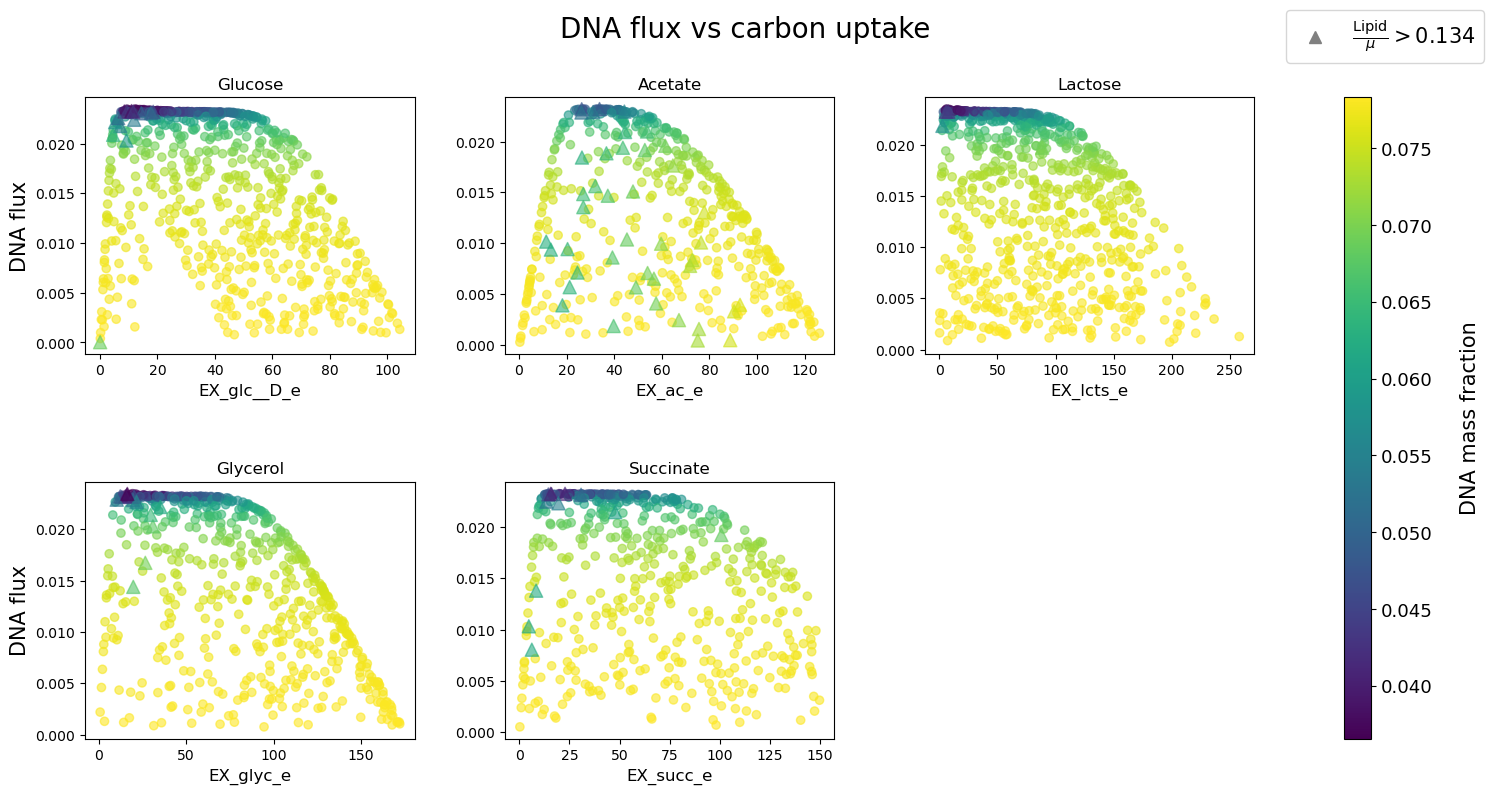

In [217]:
fig, axes = plot_by_source_subplots(
    plot_df=bm_comp,
    y_col='DNA',
    color_col = 'DNA_frac',
    source_to_xcol=source_to_ex,
    sources_to_plot=carbon_plot,
    dataset=data,
    cmap ='viridis',
    ncols=3,
    outlier_col='outlier',
    outlier_marker = '^',
    outlier_size = 90,
    y_label = 'DNA flux',
    colorbar_label = 'DNA mass fraction',
    outlier_label= r'$\frac{\mathrm{Lipid}}{\mu} > 0.134$'
)

# plt.suptitle('Protein mass fraction across sampled carbon phenotype phase planes', fontsize=20)
plt.suptitle('DNA flux vs carbon uptake', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.subplots_adjust(hspace=0.5)

axes[0].set_title("Glucose")
axes[1].set_title("Acetate")
axes[2].set_title("Lactose")
axes[3].set_title("Glycerol")
axes[4].set_title("Succinate")


axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[4].set_ylabel("")

plt.show()

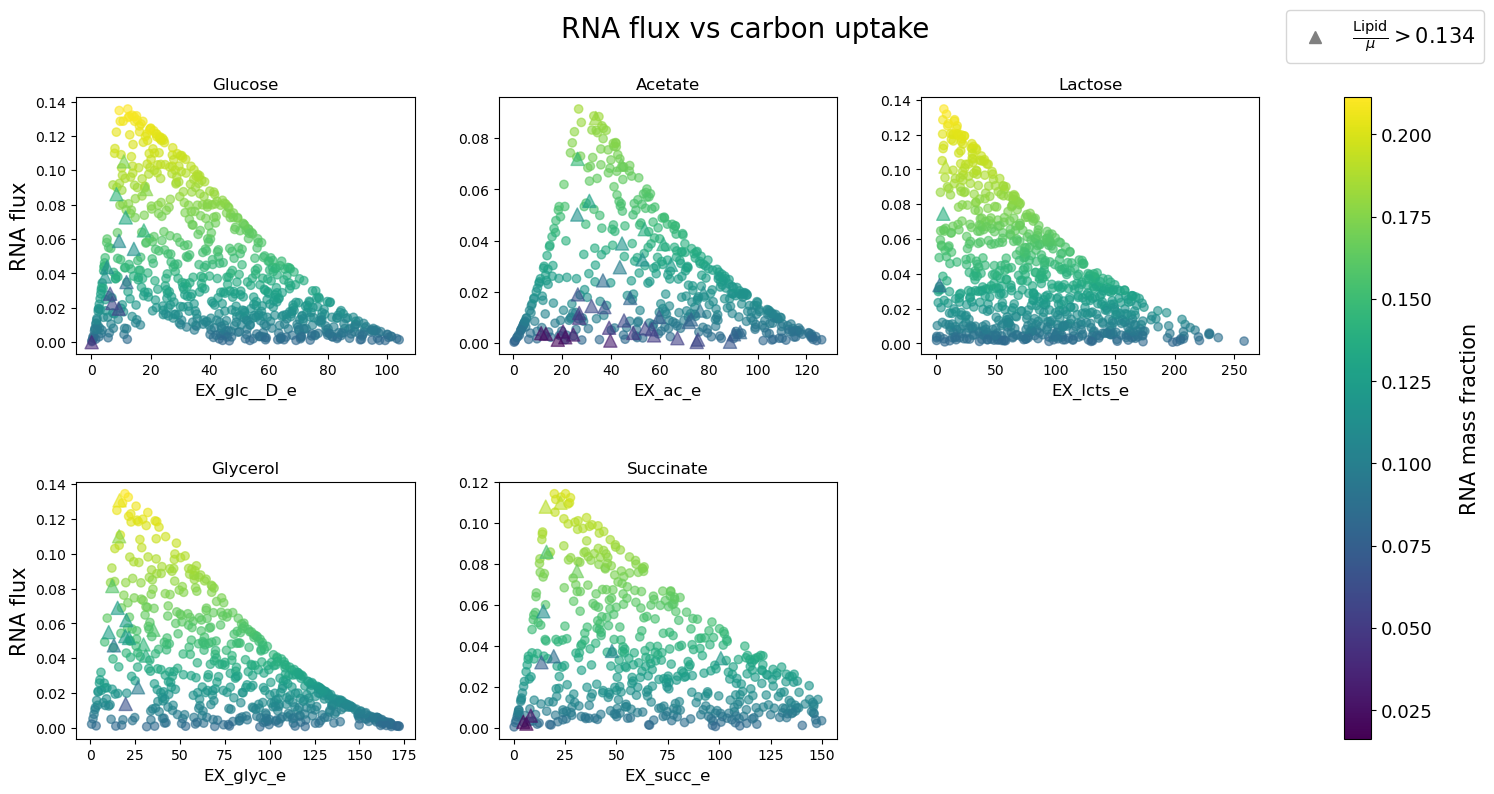

In [218]:
fig, axes = plot_by_source_subplots(
    plot_df=bm_comp,
    y_col='RNA',
    color_col = 'RNA_frac',
    source_to_xcol=source_to_ex,
    sources_to_plot=carbon_plot,
    dataset=data,
    cmap ='viridis',
    ncols=3,
    outlier_col='outlier',
    outlier_marker = '^',
    outlier_size = 90,
    y_label = 'RNA flux',
    colorbar_label = 'RNA mass fraction',
    outlier_label= r'$\frac{\mathrm{Lipid}}{\mu} > 0.134$'
)

# plt.suptitle('Protein mass fraction across sampled carbon phenotype phase planes', fontsize=20)
plt.suptitle('RNA flux vs carbon uptake', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.subplots_adjust(hspace=0.5)

axes[0].set_title("Glucose")
axes[1].set_title("Acetate")
axes[2].set_title("Lactose")
axes[3].set_title("Glycerol")
axes[4].set_title("Succinate")


axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[4].set_ylabel("")

plt.show()

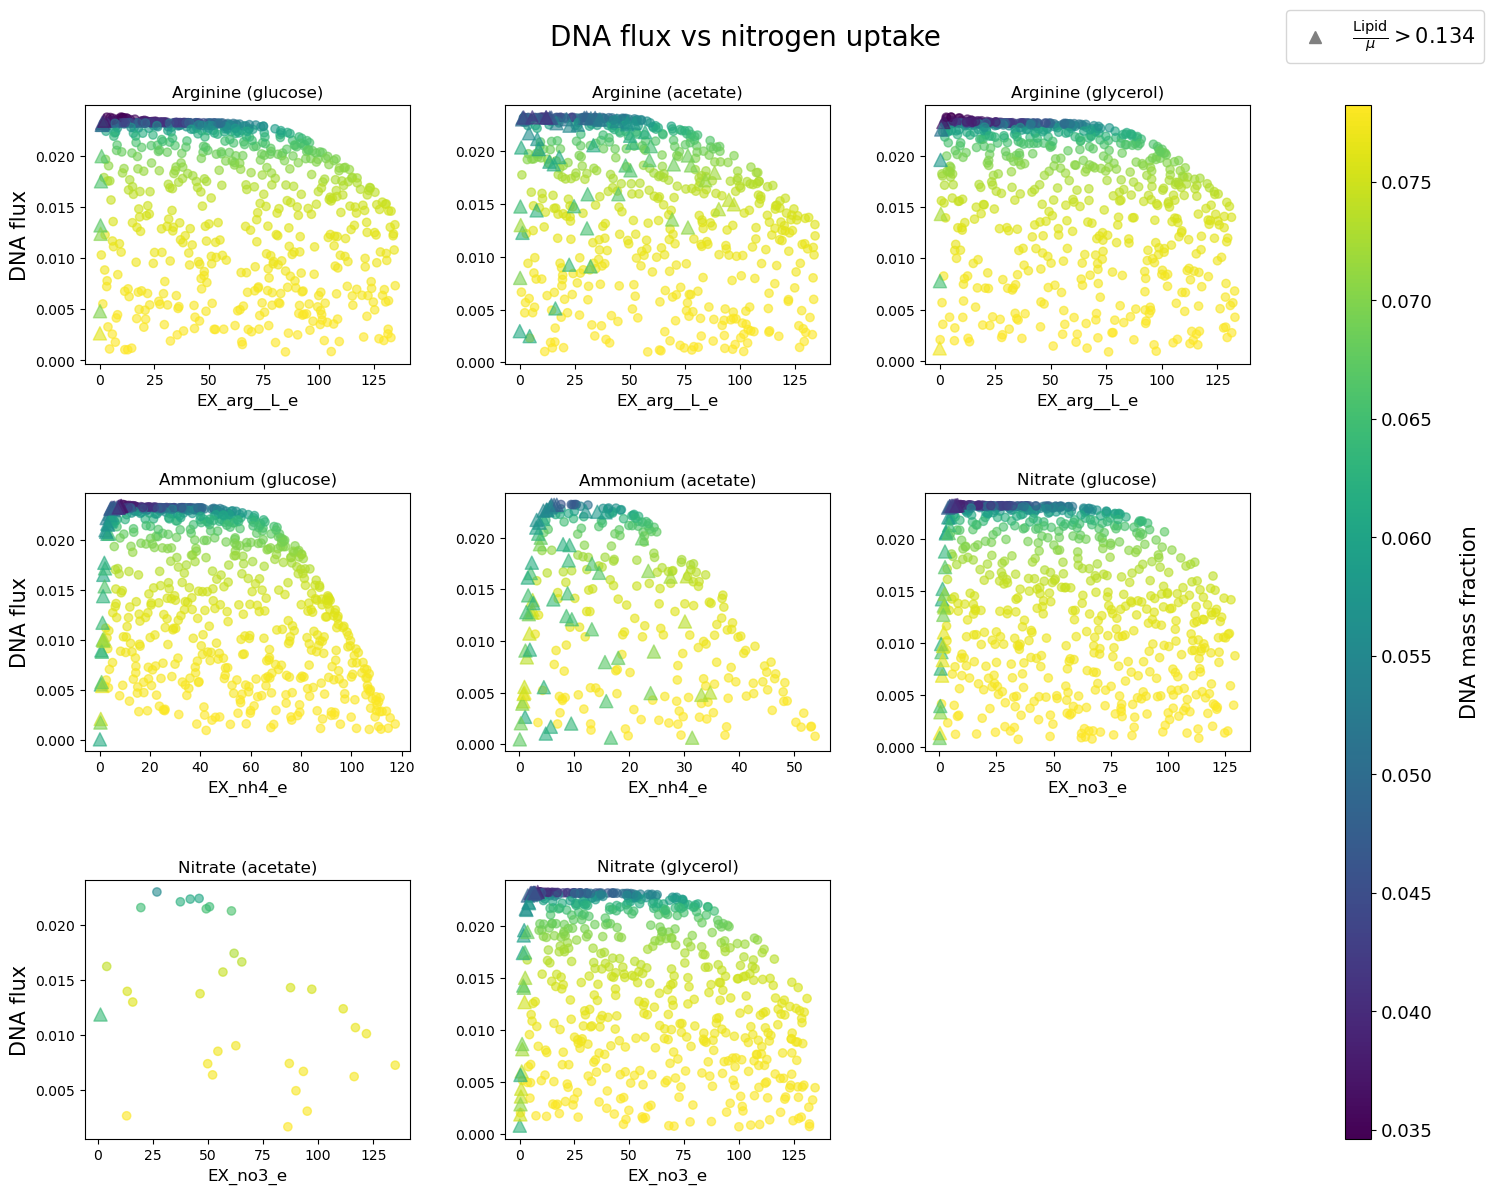

In [219]:
fig, axes = plot_by_source_subplots(
    plot_df=bm_comp,
    y_col='DNA',
    color_col = 'DNA_frac',
    source_to_xcol=source_to_ex,
    sources_to_plot=nitrogen_plot,
    dataset=data,
    cmap ='viridis',
    ncols=3,
    outlier_col='outlier',
    outlier_marker = '^',
    outlier_size = 90,
    y_label = 'DNA flux',
    colorbar_label = 'DNA mass fraction',
    outlier_label= r'$\frac{\mathrm{Lipid}}{\mu} > 0.134$'  
)

plt.suptitle('DNA flux vs nitrogen uptake', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.subplots_adjust(hspace=0.5)

axes[0].set_title("Arginine (glucose)")
axes[1].set_title("Arginine (acetate)")
axes[2].set_title("Arginine (glycerol)")
axes[3].set_title("Ammonium (glucose)")
axes[4].set_title("Ammonium (acetate)")
axes[5].set_title("Nitrate (glucose)")
axes[6].set_title("Nitrate (acetate)")
axes[7].set_title("Nitrate (glycerol)")


axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[4].set_ylabel("")
axes[5].set_ylabel("")
axes[7].set_ylabel("")


# # pos1 = axes[6].get_position()
# # pos2 = axes[7].get_position()

# # axes[6].set_position([0.15, pos1.y0, pos1.width, pos1.height])
# # axes[7].set_position([0.60, pos2.y0, pos2.width, pos2.height])
plt.show()

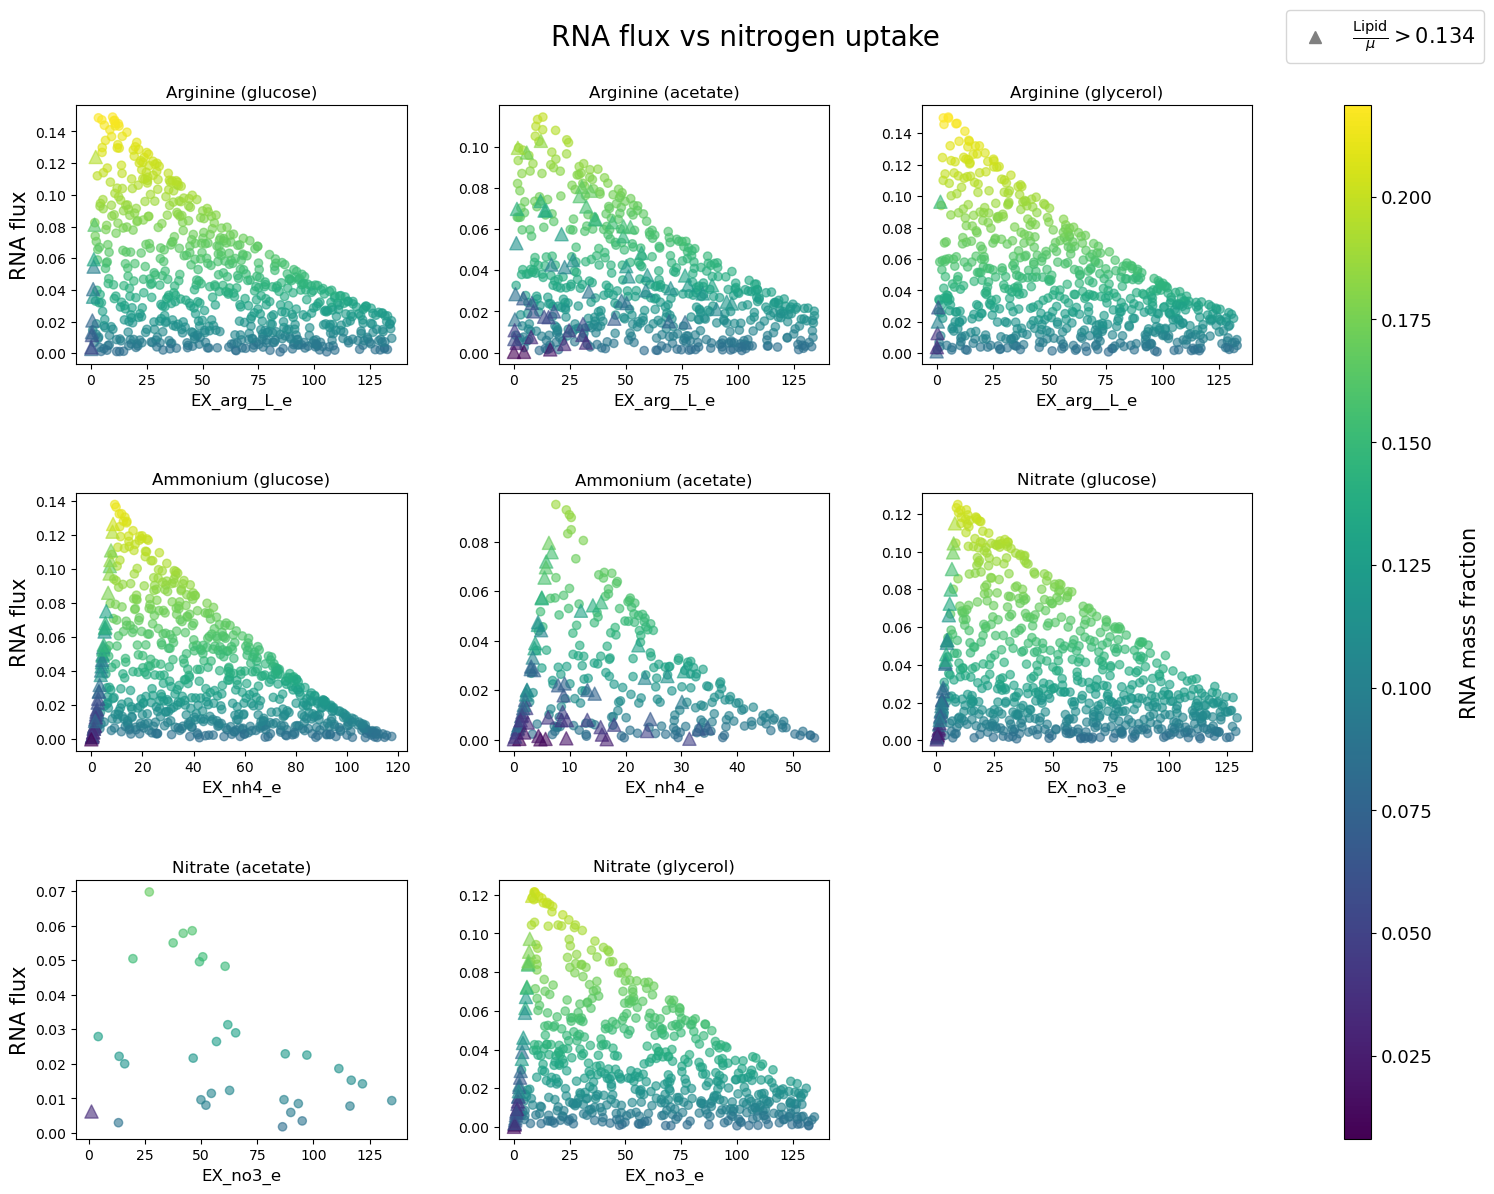

In [220]:
fig, axes = plot_by_source_subplots(
    plot_df=bm_comp,
    y_col='RNA',
    color_col = 'RNA_frac',
    source_to_xcol=source_to_ex,
    sources_to_plot=nitrogen_plot,
    dataset=data,
    cmap ='viridis',
    ncols=3,
    outlier_col='outlier',
    outlier_marker = '^',
    outlier_size = 90,
    y_label = 'RNA flux',
    colorbar_label = 'RNA mass fraction',
    outlier_label= r'$\frac{\mathrm{Lipid}}{\mu} > 0.134$'  
)

plt.suptitle('RNA flux vs nitrogen uptake', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.subplots_adjust(hspace=0.5)

axes[0].set_title("Arginine (glucose)")
axes[1].set_title("Arginine (acetate)")
axes[2].set_title("Arginine (glycerol)")
axes[3].set_title("Ammonium (glucose)")
axes[4].set_title("Ammonium (acetate)")
axes[5].set_title("Nitrate (glucose)")
axes[6].set_title("Nitrate (acetate)")
axes[7].set_title("Nitrate (glycerol)")


axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[4].set_ylabel("")
axes[5].set_ylabel("")
axes[7].set_ylabel("")


# # pos1 = axes[6].get_position()
# # pos2 = axes[7].get_position()

# # axes[6].set_position([0.15, pos1.y0, pos1.width, pos1.height])
# # axes[7].set_position([0.60, pos2.y0, pos2.width, pos2.height])
plt.show()

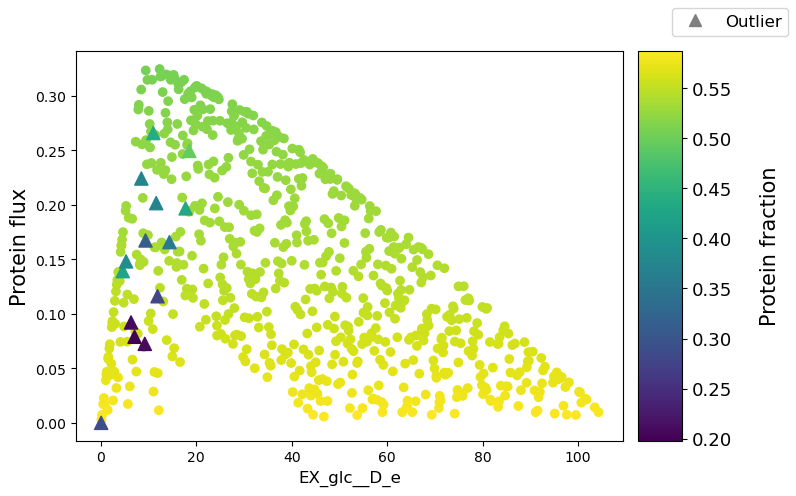

In [207]:
fig, axes = plot_by_source_subplots(
    plot_df=bm_comp,
    y_col='protein',
    color_col = 'protein_frac',
    source_to_xcol=source_to_ex,
    sources_to_plot=['glc'],
    dataset=data,
    cmap ='viridis',
    ncols=1,
    outlier_col='outlier',
    outlier_marker = '^',
    outlier_size = 90,
    y_label = 'Protein flux',
    colorbar_label = 'Protein fraction',
    point_alpha=1.0
)

axes[0].set_title("hh", color='white')

# plt.suptitle('Protein mass fraction across sampled carbon phenotype phase planes', fontsize=20)
plt.suptitle('', fontsize=20)

fig = plt.gcf()
fig.set_size_inches(8, 5)
plt.tight_layout()
plt.show()

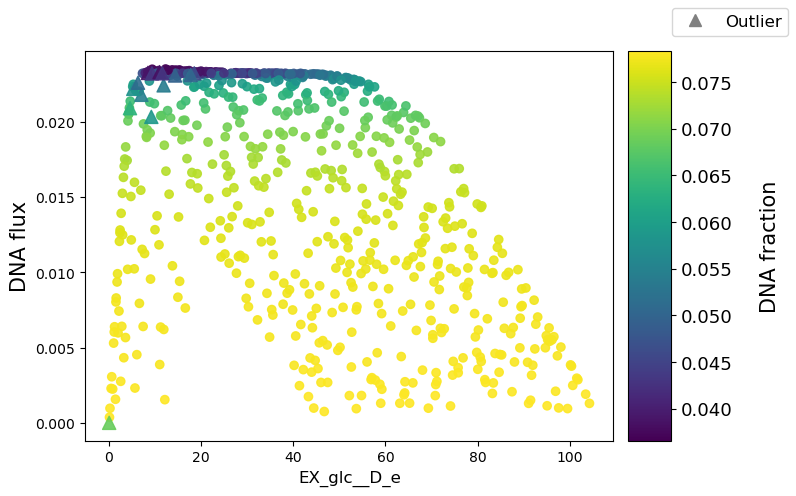

In [204]:
fig, axes = plot_by_source_subplots(
    plot_df=bm_comp,
    y_col='DNA',
    color_col = 'DNA_frac',
    source_to_xcol=source_to_ex,
    sources_to_plot=['glc'],
    dataset=data,
    cmap ='viridis',
    ncols=1,
    outlier_col='outlier',
    outlier_marker = '^',
    outlier_size = 90,
    y_label = 'DNA flux',
    colorbar_label = 'DNA fraction',
    point_alpha=0.9,

)

axes[0].set_title("hh", color='white')

# plt.suptitle('Protein mass fraction across sampled carbon phenotype phase planes', fontsize=20)
plt.suptitle('', fontsize=20)

fig = plt.gcf()
fig.set_size_inches(8, 5)
plt.tight_layout()
plt.show()

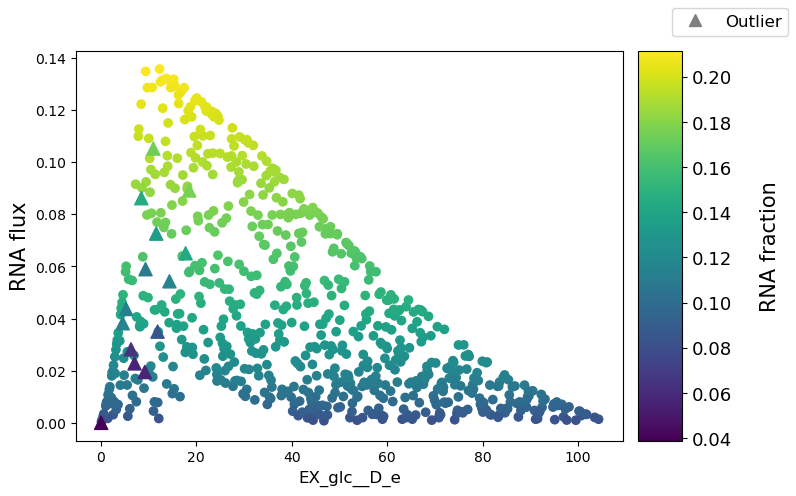

In [205]:
fig, axes = plot_by_source_subplots(
    plot_df=bm_comp,
    y_col='RNA',
    color_col = 'RNA_frac',
    source_to_xcol=source_to_ex,
    sources_to_plot=['glc'],
    dataset=data,
    cmap ='viridis',
    ncols=1,
    outlier_col='outlier',
    outlier_marker = '^',
    outlier_size = 90,
    y_label = 'RNA flux',
    colorbar_label = 'RNA fraction',
    point_alpha=1.0
)

axes[0].set_title("hh", color='white')

# plt.suptitle('Protein mass fraction across sampled carbon phenotype phase planes', fontsize=20)
plt.suptitle('', fontsize=20)

fig = plt.gcf()
fig.set_size_inches(8, 5)
plt.tight_layout()
plt.show()

# Growth rate normalization:

In [4]:
glc = data[data['source'] == 'glc']

In [34]:
check=glc.iloc[:, :13]

check['EX_o2_e'] = glc['EX_o2_e']
check['EX_glc__D_e'] = glc['EX_glc__D_e']

glc_check = check[check['biomass_dilution']<0.637]

In [36]:
glc_check.sort_values(by='biomass_dilution', ascending=False).head(10)

reaction,sample,protein_biomass_to_biomass,mRNA_biomass_to_biomass,tRNA_biomass_to_biomass,rRNA_biomass_to_biomass,ncRNA_biomass_to_biomass,DNA_biomass_to_biomass,lipid_biomass_to_biomass,constituent_biomass_to_biomass,prosthetic_group_biomass_to_biomass,peptidoglycan_biomass_to_biomass,dummy_protein_to_mass,biomass_dilution,EX_o2_e,EX_glc__D_e
162,glc_sample_162,0.257976,0.001812,0.011005,0.078599,0.000109,0.023203,0.085420,0.016279,0.000393,0.016743,0.004305,0.636651,-30.829509,-7.283033
579,glc_sample_579,0.257482,0.001808,0.010980,0.078446,0.000102,0.023203,0.085261,0.016251,0.000473,0.016714,0.004296,0.635554,-50.633764,-14.586236
248,glc_sample_248,0.256461,0.001796,0.010908,0.077930,0.000104,0.023202,0.084899,0.016182,0.000466,0.016643,0.004279,0.632853,-46.617180,-18.156077
387,glc_sample_387,0.255562,0.001784,0.010837,0.077403,0.000097,0.023201,0.084583,0.016120,0.000499,0.016579,0.004264,0.630419,-37.293454,-8.607834
299,glc_sample_299,0.255371,0.001783,0.010832,0.077375,0.000105,0.023201,0.084510,0.016107,0.000435,0.016567,0.004261,0.629932,-22.981983,-35.263603
294,glc_sample_294,0.255184,0.001782,0.010818,0.077287,0.000101,0.023201,0.084446,0.016096,0.000463,0.016555,0.004258,0.629474,-50.405420,-15.543930
657,glc_sample_657,0.254919,0.001779,0.010800,0.077155,0.000103,0.023201,0.084352,0.016078,0.000460,0.016536,0.004254,0.628773,-47.369482,-18.071689
373,glc_sample_373,0.167419,0.001167,0.007085,0.050606,0.000091,0.023200,0.250350,0.016028,0.000241,0.016485,0.002794,0.626846,-7.442252,-9.348580
663,glc_sample_663,0.252670,0.001751,0.010635,0.075969,0.000093,0.023198,0.083554,0.015924,0.000472,0.016378,0.004216,0.622772,-43.954441,-10.304308
448,glc_sample_448,0.251708,0.001741,0.010574,0.075522,0.000118,0.023196,0.083196,0.015857,0.000332,0.016309,0.004200,0.620140,-4.737032,-40.103757


In [28]:
ac = data[data['source'] == 'ac']


check = ac.iloc[:, :13]

check['EX_o2_e'] = ac['EX_o2_e']
check['EX_ac_e'] = ac['EX_ac_e']

In [28]:
bm_norm = data.iloc[:, 1:13]

In [29]:
rna_cols = bm_norm['mRNA_biomass_to_biomass'] + bm_norm['rRNA_biomass_to_biomass'] + bm_norm['tRNA_biomass_to_biomass'] + bm_norm['ncRNA_biomass_to_biomass']
bm_norm.insert(1, 'RNA_biomass_to_biomass', rna_cols)

bm_norm.drop(columns=['mRNA_biomass_to_biomass', 'rRNA_biomass_to_biomass', 'tRNA_biomass_to_biomass' ,'ncRNA_biomass_to_biomass'], inplace=True)

In [31]:
cols = bm_norm.columns.difference(['biomass_dilution'])

bm_norm[cols] = bm_norm[cols].div(
    bm_norm['biomass_dilution'],
    axis=0
)

In [32]:
bm_norm.columns = bm_norm.columns.str.split('_').str[0]
bm_norm = bm_norm.rename(columns={'dummy': 'dummy protein'})

In [33]:
bm_norm['source'] = data['source']
bm_norm.drop(columns=['lipid', 'constituent', 'dummy protein', 'peptidoglycan'], inplace=True)

In [8]:
# import matplotlib.pyplot as plt
# import pandas as pd

# colors = sns.color_palette("deep", 4)

# source_order = [
#     'glc', 'ac', 'lcts', 'glyc', 'succ',
#     'arg_glc', 'arg_ac', 'arg_glyc',
#     'nh4_glc', 'nh4_ac',
#     'no3_glc', 'no3_ac', 'no3_glyc'
# ]

# bm_norm['source'] = pd.Categorical(
#     bm_norm['source'],
#     categories=source_order,
#     ordered=True
# )

# numeric_cols = bm_norm.select_dtypes(include='number').columns

# for col in numeric_cols:
#     stats = (
#         bm_norm
#         .groupby('source', observed=False)[col]
#         .describe()
#         .reindex(source_order)
#     )

#     ax = stats[['mean', '50%', 'min', 'max']].plot(
#         kind='bar',
#         figsize=(13, 6),
#         color=colors
#     )

#     ax.set_title(f'')
#     ax.set_xlabel('')
#     ax.set_ylabel(f'{col} flux')
#     # ax.set_yscale('log')

#     ax.tick_params(axis='x', rotation=0)
#     ax.legend(
#         title='Statistic',
#         bbox_to_anchor=(1.02, 1),
#         loc='upper left'
#     )

#     plt.tight_layout()
#     plt.show()

In [154]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def plot_source_stats(
    df,
    cols,
    source_order,
    panel_letter=None,
    yscale=None,
    colors=None,
    include_stat=None
):  

   
    if colors is not None:
        colors = colors
    else:
        colors = sns.color_palette("deep", 4)

    df = df.copy()
    df["source"] = pd.Categorical(
        df["source"],
        categories=source_order,
        ordered=True
    )

    for col in cols:

        stats = (
            df
            .groupby("source", observed=False)[col]
            .describe()
            .reindex(source_order)
        )

        fig, ax = plt.subplots(figsize=(13, 6))
    
    
        # stats[["mean", "50%", "min", "max"]].plot(
        #     kind="bar",
        #     ax=ax,
        #     color=colors
        # )


        stats[["min"]].plot(
             kind="bar",
             ax=ax,
             color=colors
         )

        ax.set_xlabel("")
        ax.set_ylabel(f"{col} flux", fontsize=15)

        if yscale is not None:
            ax.set_yscale(yscale)


        ax.tick_params(axis="x", rotation=0, labelsize=12)

        ax.legend(
            title="Statistic",
            bbox_to_anchor=(1.02, 1),
            loc="upper left"
        )

        # Panel label
        if panel_letter is not None:
            ax.text(
                -0.08, 1.05,
                panel_letter,
                transform=ax.transAxes,
                fontsize=20,
                fontweight="bold",
                va="top"
            )

        plt.tight_layout()
        plt.show()

In [105]:
source_order = [
    'glc', 'ac', 'lcts', 'glyc', 'succ',
    'arg_glc', 'arg_ac', 'arg_glyc',
    'nh4_glc', 'nh4_ac',
    'no3_glc', 'no3_ac', 'no3_glyc'
]

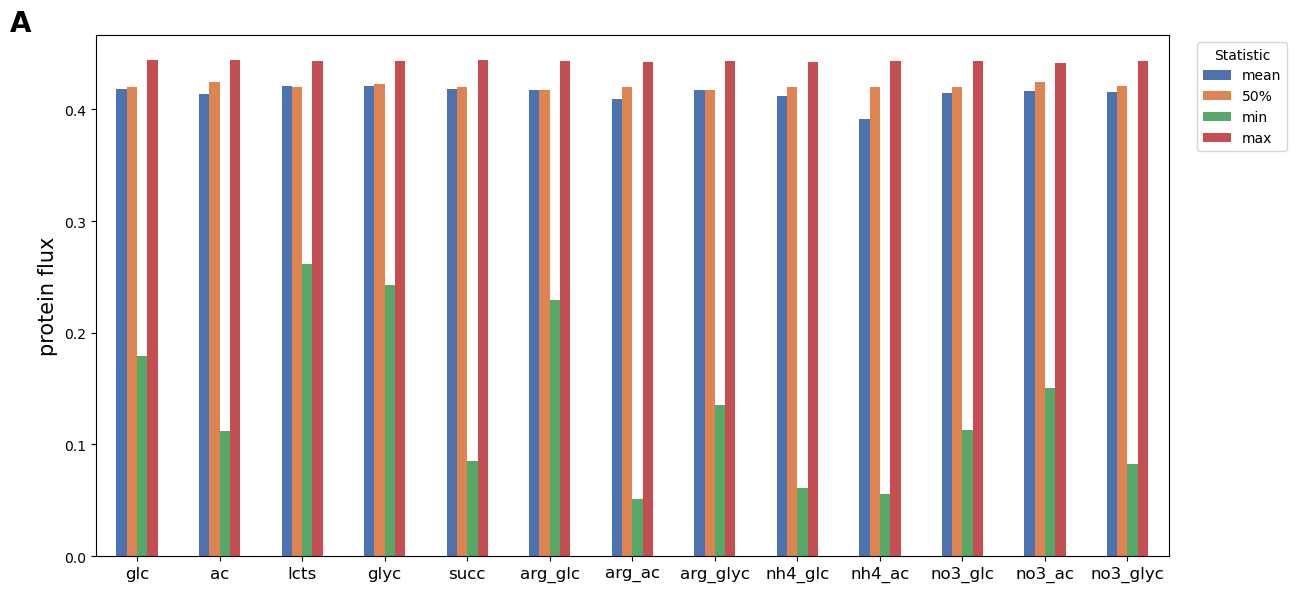

In [139]:
plot_source_stats(bm_norm, cols=["protein"], source_order=source_order, panel_letter="A", colors="deep")

In [159]:
crest = sns.color_palette("crest", as_cmap=True)



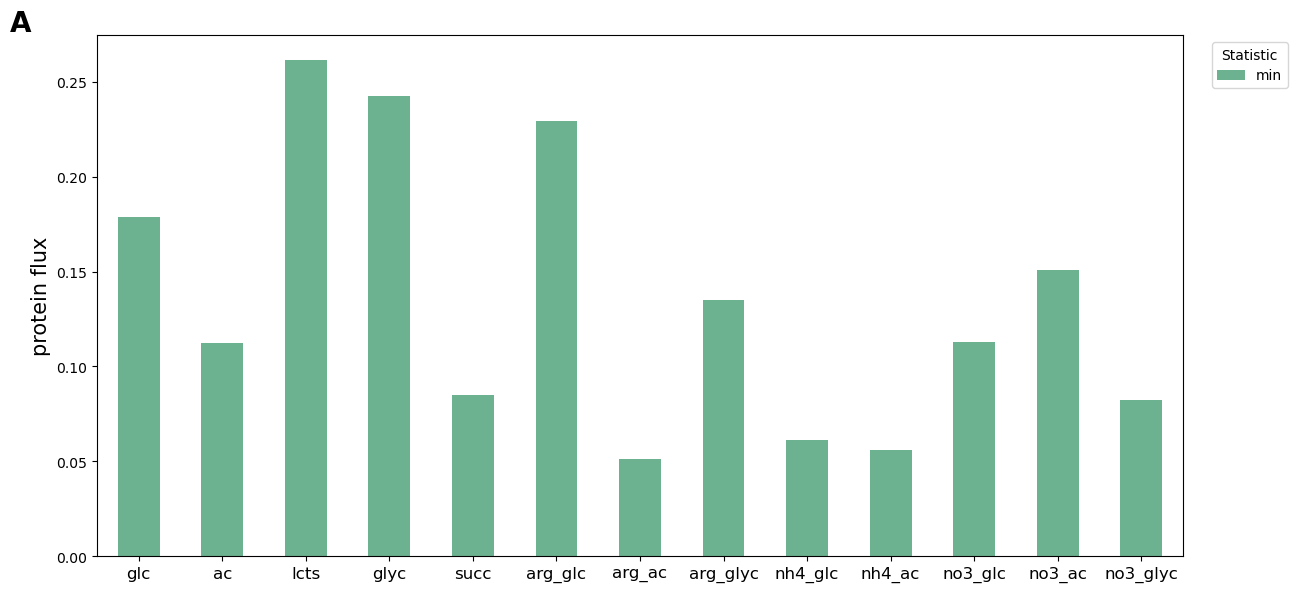

In [161]:
plot_source_stats(bm_norm, cols=["protein"], source_order=source_order, panel_letter="A", colors=crest(0.2))

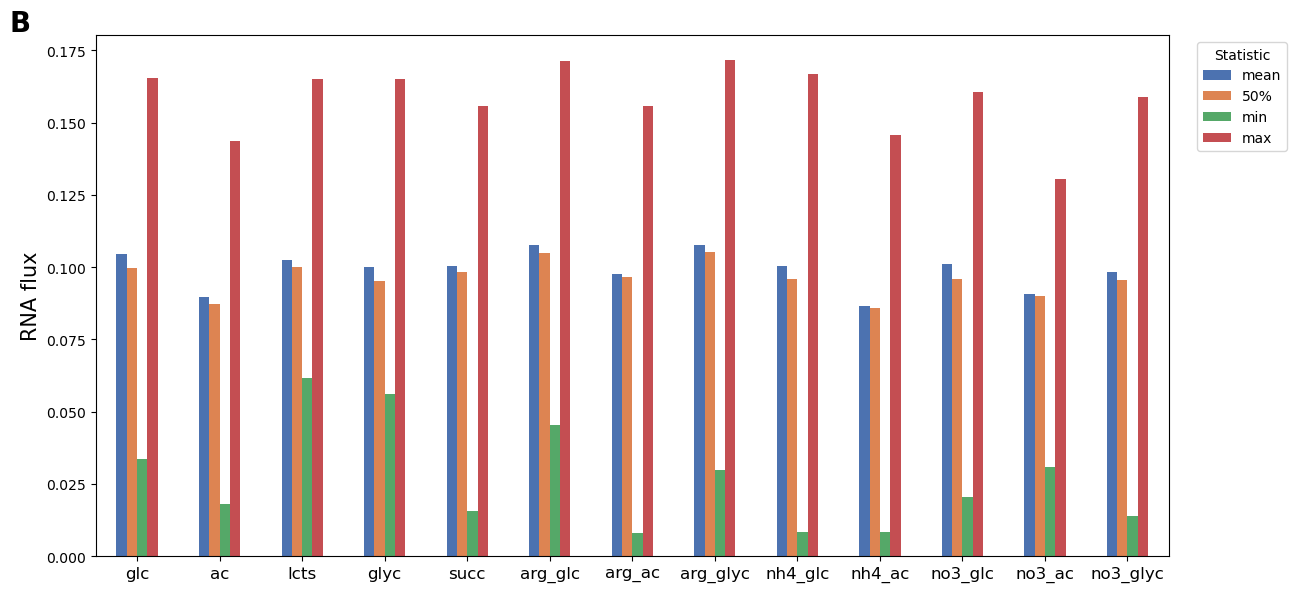

In [141]:
plot_source_stats(bm_norm, cols=["RNA"], source_order=source_order, panel_letter="B")

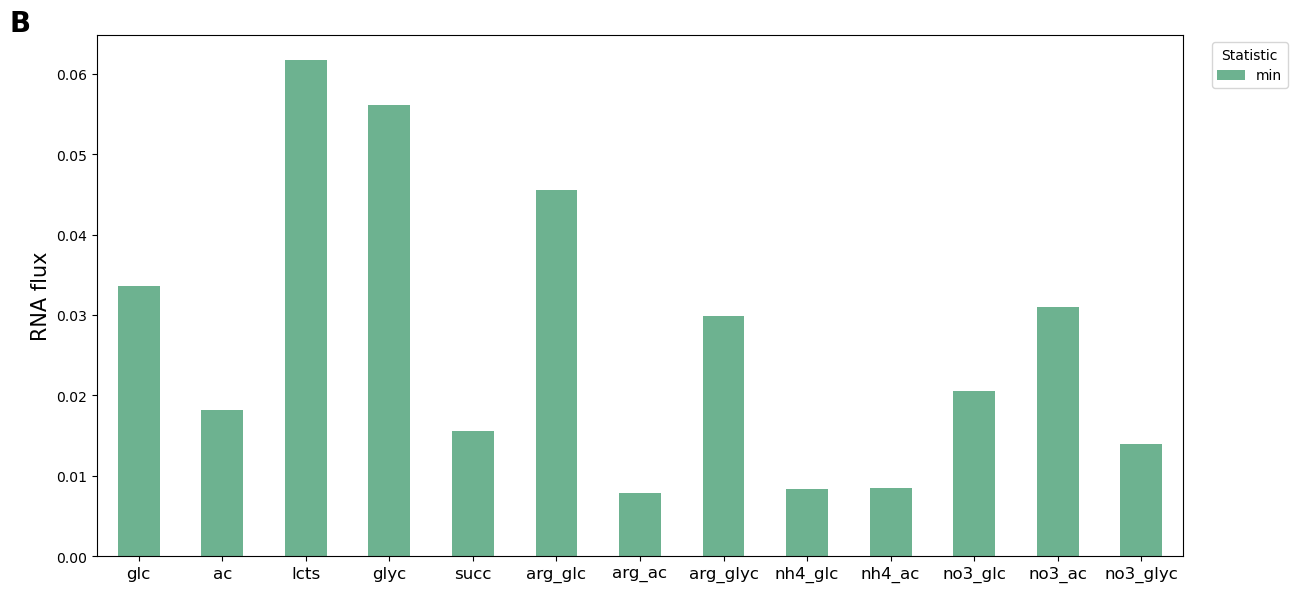

In [163]:
plot_source_stats(bm_norm, cols=["RNA"], source_order=source_order, panel_letter="B", colors=crest(0.2))

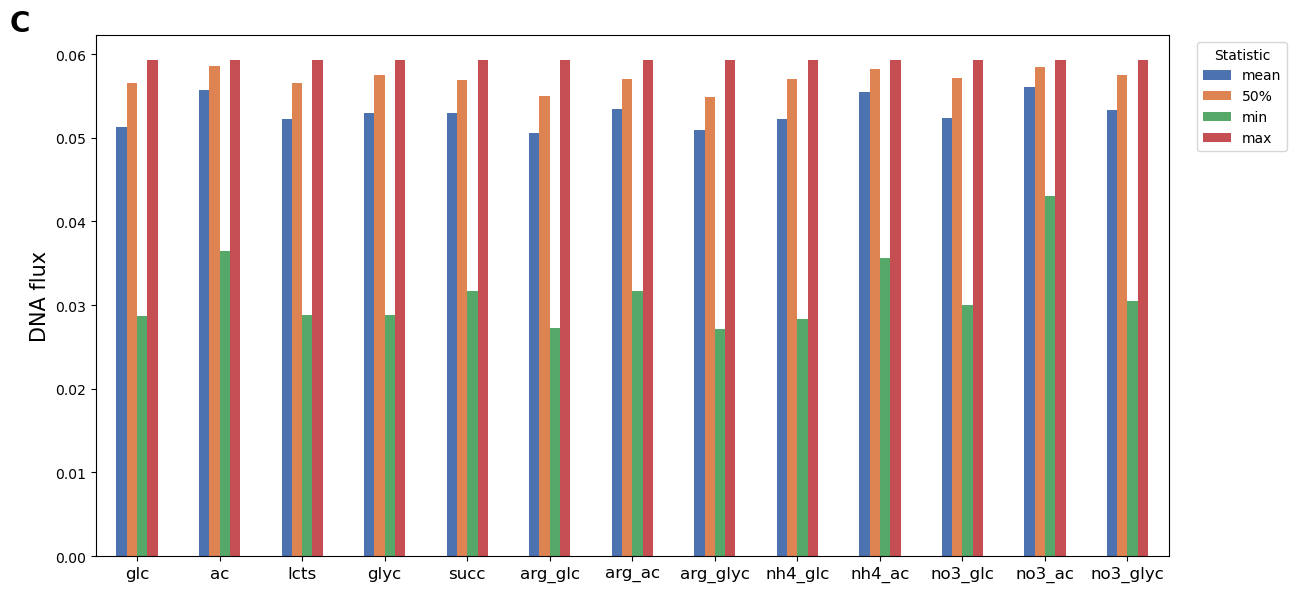

In [143]:
plot_source_stats(bm_norm, cols=["DNA"], source_order=source_order, panel_letter="C")

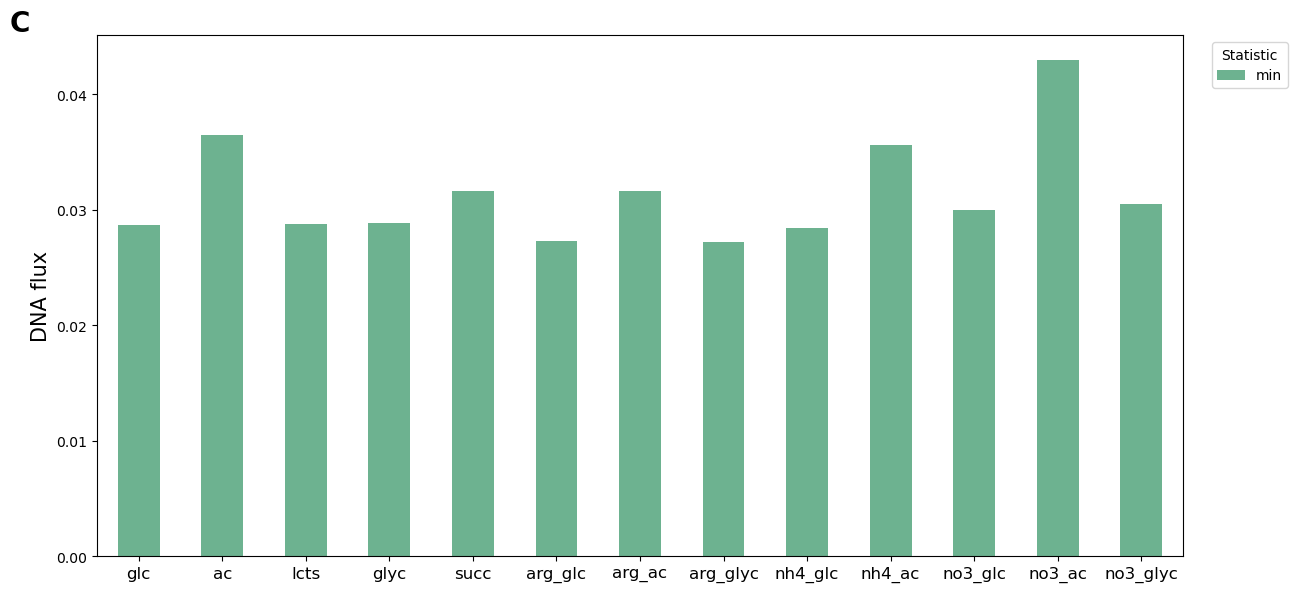

In [164]:
plot_source_stats(bm_norm, cols=["DNA"], source_order=source_order, panel_letter="C", colors=crest(0.2))

## garPLRK

In [46]:
test = pd.read_pickle("/triumvirate/home/celinaha/thesis_files/data/ml_datasets2/L2_IID_TEST.pkl")

In [48]:
test['source'].value_counts()

source
lcts        157
glc         141
no3_glc     138
nh4_glc     137
arg_glc     133
arg_glyc    131
no3_glyc    119
arg_ac      117
glyc        116
succ        102
ac           96
nh4_ac       58
no3_ac        7
Name: count, dtype: int64

In [43]:
import pandas as pd
df = pd.read_pickle(DATA/"final_data/internal_biomass.pkl")

In [44]:
gar = ["b3124", "b3125", "b3126", "b3127", "b0507", "b2975", "b4014"]

prot = df[df["biomass_type"]=="protein"]
prot.drop(columns='biomass_type', inplace=True)

gar_df = prot[
    prot["reaction"].apply(
        lambda x: any(g in str(x) for g in gar)
    )
]

In [45]:
sample_cols = [c for c in gar_df.columns if '_sample_' in c]

gar_nonzero = gar_df[(gar_df[sample_cols] != 0).any(axis=1)]

env_order = ['glc', 'ac', 'lcts', 'glyc', 'succ', 'arg_glc', 'arg_ac', 'arg_glyc',
             'nh4_glc', 'nh4_ac', 'no3_glc', 'no3_ac', 'no3_glyc']

sources = pd.Series(sample_cols, index=sample_cols).str.split('_sample_').str[0]
active = gar_nonzero[sample_cols] > 0  

counts_per_source = active.T.groupby(sources).sum().T
counts_per_source.index = gar_nonzero['reaction']
# counts = by_source_any.groupby(all_dfs['reaction']).sum()

counts_per_source = counts_per_source.reindex(columns=env_order)
counts_per_source

,glc,ac,lcts,glyc,succ,arg_glc,arg_ac,arg_glyc,nh4_glc,nh4_ac,no3_glc,no3_ac,no3_glyc
reaction,,,,,,,,,,,,,
translation_b0507,54,0,2,192,465,0,556,106,56,0,0,0,2
translation_b2975,12,47,4,5,9,0,0,1,1,3,0,0,1
translation_b3124,27,0,2,192,1,0,0,106,56,0,0,0,2
translation_b3125,54,1,2,193,436,0,510,106,56,0,0,0,2
translation_b3127,27,0,0,0,1,0,0,0,0,0,0,0,0
translation_b4014,607,482,706,362,32,613,27,528,602,291,683,33,592


In [7]:
rna_df = df[df['biomass_type'].str.contains('RNA')]
nc = rna_df[rna_df['biomass_type']=='ncRNA']

sample_cols = [c for c in df.columns if '_sample_' in c]

nc_nonzero = nc[(nc[sample_cols] != 0).any(axis=1)]

sources = pd.Series(sample_cols, index=sample_cols).str.split('_sample_').str[0]
active = nc_nonzero[sample_cols] > 0  

counts_per_source = active.T.groupby(sources).sum().T
counts_per_source.index = nc_nonzero['reaction']
# counts = by_source_any.groupby(all_dfs['reaction']).sum()

counts_per_source = counts_per_source.reindex(columns=env_order)
counts_per_source

,glc,ac,lcts,glyc,succ,arg_glc,arg_ac,arg_glyc,nh4_glc,nh4_ac,no3_glc,no3_ac,no3_glyc
reaction,,,,,,,,,,,,,
ncRNA_biomass_to_biomass,703,482,786,580,509,667,583,653,685,291,689,33,596
transcription_TU482_with_TERM161_from_RpoD_mono_ncRNA,54,0,2,192,436,0,510,106,56,0,0,0,2
transcription_TU543_with_TERM0281_from_RpoD_mono,0,0,0,0,0,0,0,0,0,1,0,0,0
transcription_TU543_with_TERM0283_from_RpoD_mono,703,482,786,580,509,667,576,653,685,290,689,33,596
transcription_TU0_12938_from_RpoD_mono,703,482,786,580,509,667,583,653,685,291,689,33,596
